# Sit. 2 — Colab: EDA + GeoVision-CLIP + **SAE** + validación

## Mapa del notebook

| Paso | Qué hace |
|------|----------|
| HF | Dataset **Slucu-0310/geovision-cali-sit2** (1350 pares, split 70/15/15) |
| EDA | Balance, calidad SCL/NDVI y **estudios** (leakage, S5P, ozono) en `eda_sit2/` |
| Informe | §4: `INFORME_DIAGNOSTICO_SIT2.md` + export `informe_diagnostico_integrado.md` |
| Diagnóstico | Tras entrenar: curvas JSON, Recall global/clase, z_img, peores 20 pares |
| Modelo | **RemoteCLIP** (`chendelong/RemoteCLIP`, `RemoteCLIP-ViT-B-32.pt`) + MiniLM + **2 SAE** |
| Train | ReLU SAE, filtro train (nube/claros), sampler balanceado, warmup InfoNCE, cosine LR, early
al/infonce |

**¿SAE?** ReLU en encoder + L1 (λ=1e-2); α=0 épocas 0-4 (solo InfoNCE), luego α=0.1.

**¿De dónde el visual?** Hugging Face → `hf_hub_download` → `load_state_dict` (método oficial ChenDelong). Solo se entrena adaptador 13→3, SAE, proyecciones y texto (RemoteCLIP congelado si `FREEZE_VISUAL=True`).


In [4]:
# @title Dependencias
%pip install -q huggingface_hub open_clip_torch zarr numcodecs pandas pyarrow numpy matplotlib seaborn scipy
%pip install -q torch torchvision pytorch-lightning transformers sentencepiece wandb tqdm
# RemoteCLIP (metodo oficial ChenDelong): pesos en chendelong/RemoteCLIP via hf_hub_download


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
# @title Hugging Face — descarga dataset
import os
from pathlib import Path

HF_REPO_ID = "Slucu-0310/geovision-cali-sit2"

def _find_dataset_dir() -> Path:
    """Colab, repo local o cwd."""
    here = Path.cwd()
    candidates = [
        Path("/content/dataset_sit2"),
        here / "dataset_sit2",
        here.parent / "dataset_sit2",
    ]
    for p in candidates:
        if (p / "metadatos.parquet").is_file() and (p / "tiles.zarr").exists():
            return p
    return Path("/content/dataset_sit2")

def _eda_run_dirs(data_dir: Path) -> tuple[Path, Path]:
    if str(data_dir).startswith("/content"):
        eda = Path("/content/eda_sit2")
        run = Path("/content/runs/sit2_clip_colab")
    else:
        eda = data_dir.parent / "eda_sit2"
        run = data_dir.parent / "runs" / "sit2_clip_colab"
    eda.mkdir(parents=True, exist_ok=True)
    run.mkdir(parents=True, exist_ok=True)
    return eda, run

DATA_DIR = _find_dataset_dir()
EDA_DIR, RUN_DIR = _eda_run_dirs(DATA_DIR)
print("DATA_DIR:", DATA_DIR, "| existe parquet:", (DATA_DIR / "metadatos.parquet").is_file())

USE_HF_DOWNLOAD = not (DATA_DIR / "metadatos.parquet").is_file()
if USE_HF_DOWNLOAD:
    try:
        from google.colab import userdata
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    except Exception:
        pass
    from huggingface_hub import login, snapshot_download
    if os.environ.get("HF_TOKEN"):
        login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)
    DATA_DIR = Path("/content/dataset_sit2")
    EDA_DIR, RUN_DIR = _eda_run_dirs(DATA_DIR)
    snapshot_download(
        repo_id=HF_REPO_ID,
        repo_type="dataset",
        local_dir=str(DATA_DIR),
        local_dir_use_symlinks=False,
    )
    print("Descargado desde HF en:", DATA_DIR)
else:
    print("Usando dataset local (sin re-descargar HF).")



DATA_DIR: /content/dataset_sit2 | existe parquet: True
Usando dataset local (sin re-descargar HF).


In [6]:
# @title Utilidades de lectura (inline)
from __future__ import annotations
import json
from typing import Any, Literal
import numpy as np
import pandas as pd
import zarr

SEED = 42
CLASES = [
    "contaminacion_alta_NO2", "contaminacion_alta_SO2", "ozono_anomalo",
    "vegetacion_densa", "suelo_urbano",
]
BANDAS_S2 = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12","SCL"]
_IDX_RGB = {"B4": 3, "B3": 2, "B2": 1}
_IDX_SCL = BANDAS_S2.index("SCL")

def tile_zarr_index(tile_id: str) -> int:
    """Indice en tiles.zarr alineado con filas del parquet."""
    pos = np.flatnonzero(df["tile_id"].values == tile_id)
    if pos.size == 0:
        raise KeyError(f"tile_id no encontrado: {tile_id}")
    return int(pos[0])

SplitName = Literal["train", "val", "test"]
NUMERIC_COLS = [
    "valid_ratio", "frac_nubes_scl", "frac_claros_scl", "frac_nodata_scl",
    "ndvi", "bsi", "no2", "so2", "o3",
]

def _zarr_store(path: str):
    try:
        return zarr.storage.LocalStore(path)
    except AttributeError:
        return zarr.DirectoryStore(path)

def open_tiles_zarr(zarr_path):
    p = str(zarr_path)
    try:
        root = zarr.open(p, mode="r")
    except Exception:
        root = zarr.open(_zarr_store(p), mode="r")
    if isinstance(root, zarr.Array):
        return root
    if "tiles" in root:
        return root["tiles"]
    for _, a in root.arrays():
        return a
    raise ValueError(p)

def compute_band_stats(zarr_path, n_sample=512, seed=SEED):
    rng = np.random.default_rng(seed)
    arr = open_tiles_zarr(zarr_path)
    n = int(arr.shape[0])
    idx = rng.choice(n, size=min(n_sample, n), replace=False)
    sample = np.stack([np.asarray(arr[i], dtype=np.float32) for i in idx])
    mean = sample.mean(axis=(0, 2, 3))
    std = np.maximum(sample.std(axis=(0, 2, 3)), 1e-3)
    return mean.astype("float32"), std.astype("float32")

def tile_to_rgb_uint8(tile_13hw, p_low=2, p_high=98):
    chans = []
    for b in ("B4", "B3", "B2"):
        x = tile_13hw[_IDX_RGB[b]].astype(np.float32)
        fin = x[np.isfinite(x)]
        lo, hi = (np.percentile(fin, [p_low, p_high]) if fin.size else (0, 1))
        if hi <= lo:
            hi = lo + 1
        chans.append((np.clip((x - lo) / (hi - lo), 0, 1) * 255).astype(np.uint8))
    return np.stack(chans, axis=-1)

META_PATH = DATA_DIR / "metadatos.parquet"
ZARR_PATH = DATA_DIR / "tiles.zarr"
df = pd.read_parquet(META_PATH)
tiles_z = open_tiles_zarr(ZARR_PATH)
secuencias = json.loads((DATA_DIR / "secuencias.json").read_text(encoding="utf-8"))
resumen = json.loads((DATA_DIR / "resumen.json").read_text(encoding="utf-8"))
assert len(df) == int(tiles_z.shape[0])
print(f"Pares: {len(df)} | tiles: {tiles_z.shape}")



Pares: 2276 | tiles: (2276, 13, 64, 64)


## 1. EDA exhaustivo (informe)

Balance, estadísticas por clase, correlaciones y muestras visuales. Salidas en `EDA_DIR`.

=== Balance global ===
 clase
contaminacion_alta_NO2    500
contaminacion_alta_SO2    276
ozono_anomalo             500
vegetacion_densa          500
suelo_urbano              500
Name: n, dtype: int64

=== Balance por split ===
 clase  contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split                                                                  
test                       75                      42             75   
train                     350                     193            350   
val                        75                      41             75   

clase  suelo_urbano  vegetacion_densa  
split                                  
test             75                75  
train           350               350  
val              75                75  


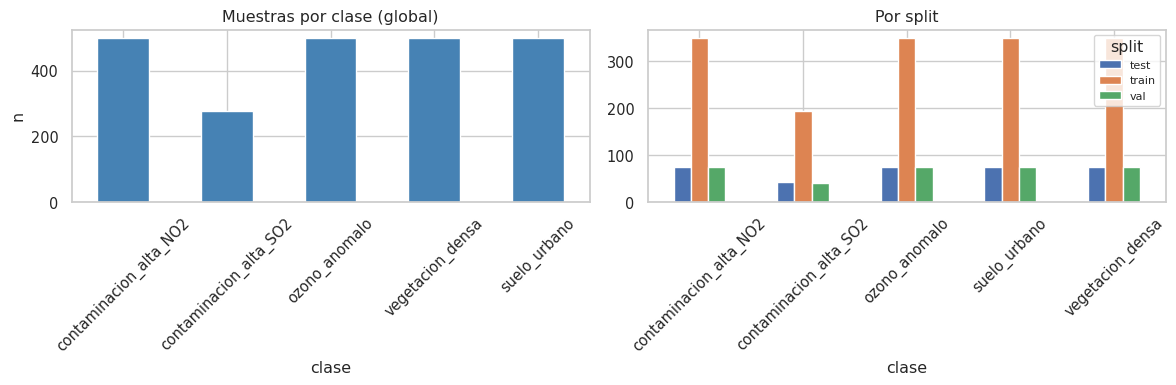


=== Estadísticas por clase (extracto NDVI/BSI/nubes) ===
                            ndvi                                          \
                            mean       std       min       max    median   
clase                                                                      
contaminacion_alta_NO2  0.462688  0.181805  0.030946  0.836661  0.490516   
contaminacion_alta_SO2  0.604261  0.131558  0.111016  0.886132  0.631494   
ozono_anomalo           0.586082  0.135775  0.124191  0.923665  0.603620   
suelo_urbano            0.463727  0.130440  0.014361  0.704629  0.490629   
vegetacion_densa        0.661450  0.082284  0.458566  0.886407  0.664144   

                             bsi                                          ...  \
                            mean       std       min       max    median  ...   
clase                                                                     ...   
contaminacion_alta_NO2 -0.056949  0.123962 -0.347509  0.157995 -0.048708  ...   
contamina

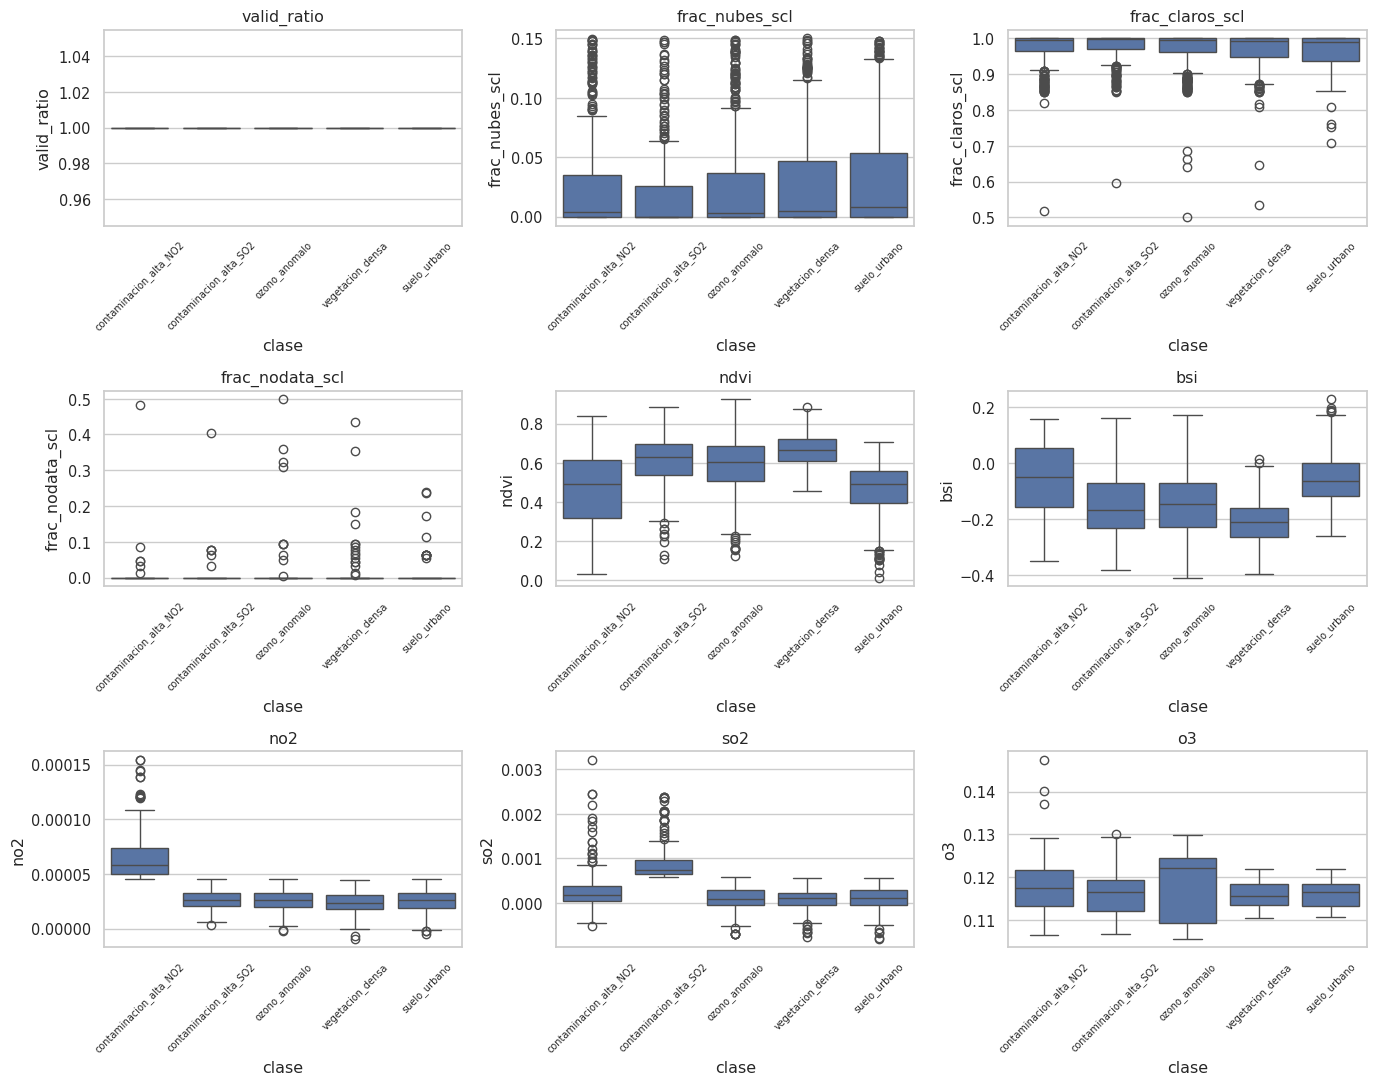

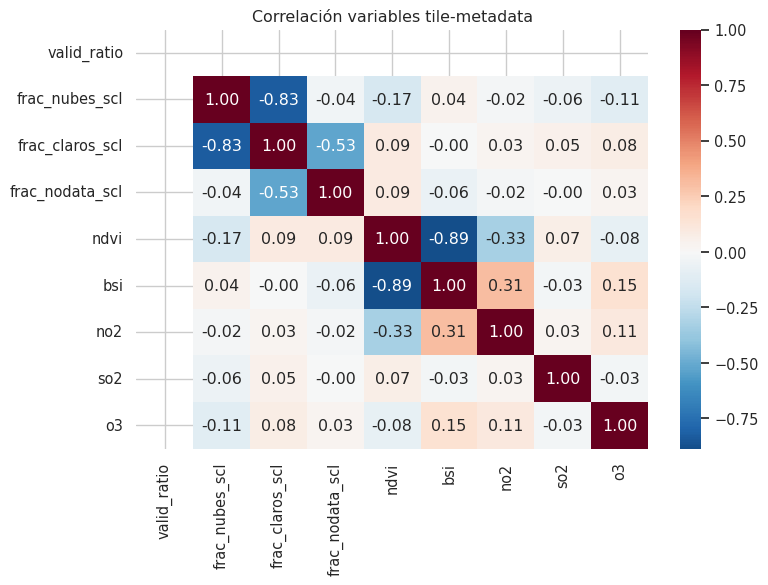

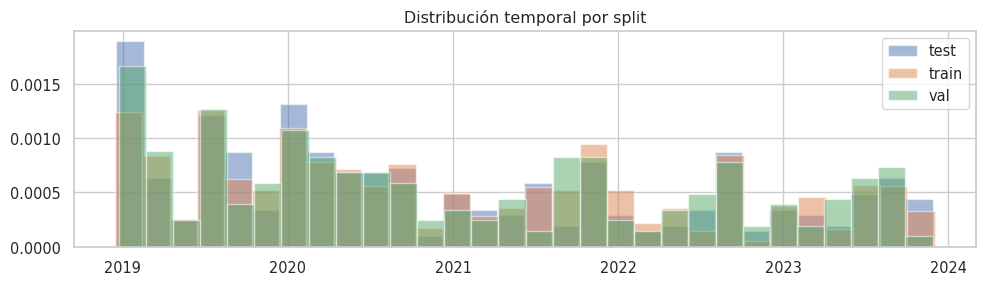

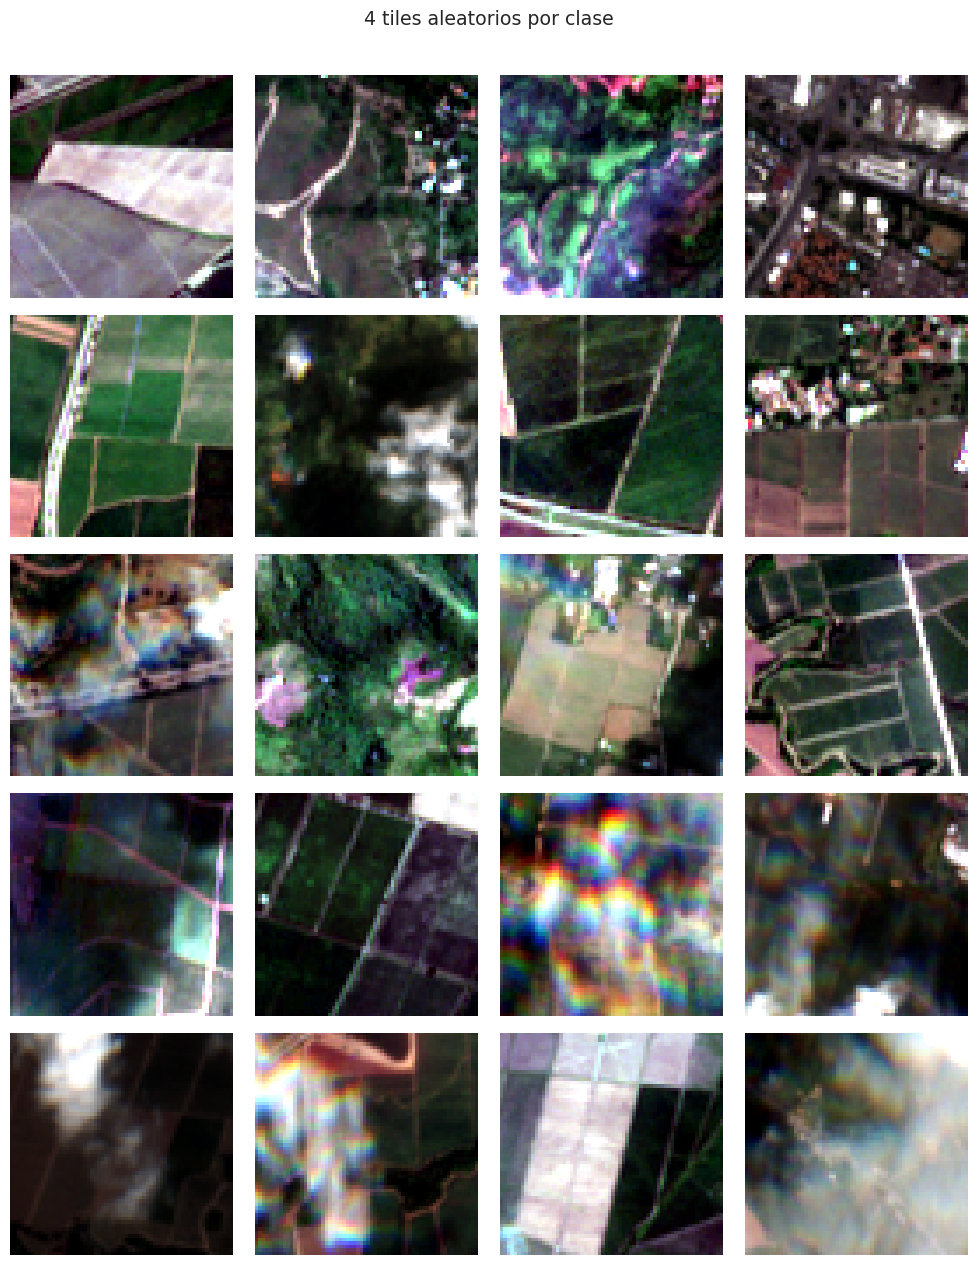


Secuencias: 30 | longitudes: [8, 8, 8, 8, 8]...
EDA guardado en: /content/eda_sit2


In [7]:
# @title EDA — tablas y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)
rng = np.random.default_rng(SEED)

# --- Balance global y por split ---
bal_global = df["clase"].value_counts().reindex(CLASES).rename("n")
bal_global.to_csv(EDA_DIR / "balance_global.csv")
print("=== Balance global ===\n", bal_global)

bal_split = df.groupby(["split", "clase"]).size().unstack(fill_value=0)
bal_split.to_csv(EDA_DIR / "balance_por_split.csv")
print("\n=== Balance por split ===\n", bal_split)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bal_global.plot(kind="bar", ax=axes[0], color="steelblue", rot=45)
axes[0].set_title("Muestras por clase (global)")
axes[0].set_ylabel("n")
bal_split.T.plot(kind="bar", ax=axes[1], rot=45)
axes[1].set_title("Por split")
axes[1].legend(title="split", fontsize=8)
plt.tight_layout()
plt.savefig(EDA_DIR / "01_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Estadísticas numéricas por clase ---
stats = df.groupby("clase")[NUMERIC_COLS].agg(["mean", "std", "min", "max", "median"])
stats.to_csv(EDA_DIR / "estadisticas_por_clase.csv")
print("\n=== Estadísticas por clase (extracto NDVI/BSI/nubes) ===")
_cols_show = ["ndvi", "bsi", "frac_nubes_scl", "no2", "so2", "o3"]
# MultiIndex: nivel 0 = variable, nivel 1 = agregación (mean, std, ...)
print(stats.loc[:, pd.IndexSlice[_cols_show, :]].round(6))

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for i, col in enumerate(NUMERIC_COLS):
    sns.boxplot(data=df, x="clase", y=col, ax=axes[i], order=CLASES)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig(EDA_DIR / "02_boxplots_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Correlación (Pearson) ---
corr = df[NUMERIC_COLS].corr()
corr.to_csv(EDA_DIR / "correlacion_numericas.csv")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlación variables tile-metadata")
plt.tight_layout()
plt.savefig(EDA_DIR / "03_correlacion.png", dpi=150)
plt.show()

# --- Fechas y splits ---
df["fecha_dt"] = pd.to_datetime(df["fecha"])
fig, ax = plt.subplots(figsize=(10, 3))
for sp, g in df.groupby("split"):
    ax.hist(g["fecha_dt"], bins=30, alpha=0.5, label=sp, density=True)
ax.legend()
ax.set_title("Distribución temporal por split")
plt.tight_layout()
plt.savefig(EDA_DIR / "04_fechas_por_split.png", dpi=150)
plt.show()

# --- Muestras RGB por clase ---
fig, axes = plt.subplots(len(CLASES), 4, figsize=(10, 2.5 * len(CLASES)))
for r, clase in enumerate(CLASES):
    sub = df[df["clase"] == clase]
    idxs = rng.choice(sub.index.to_numpy(), size=min(4, len(sub)), replace=False)
    for c, j in enumerate(idxs):
        tile = np.asarray(tiles_z[int(j)])
        axes[r, c].imshow(tile_to_rgb_uint8(tile))
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(clase, fontsize=8)
plt.suptitle("4 tiles aleatorios por clase", y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / "05_muestras_rgb_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Secuencias temporales (Sit. 3) ---
seq_lens = [len(s["tile_ids"]) for s in secuencias]
seq_df = pd.DataFrame({
    "n_secuencias": [len(secuencias)],
    "longitud_media": [np.mean(seq_lens)],
    "longitud_min": [min(seq_lens)],
    "longitud_max": [max(seq_lens)],
})
seq_df.to_csv(EDA_DIR / "resumen_secuencias.csv", index=False)
print(f"\nSecuencias: {len(secuencias)} | longitudes: {seq_lens[:5]}...")
print("EDA guardado en:", EDA_DIR)


## 2. EDA — calidad para entrenamiento

Informe complementario: nubes (SCL), claridad y NDVI por **split** y **clase**.
Salidas en `EDA_DIR` (`resumen_calidad_split_clase.csv`, `tiles_baja_calidad.csv`, paneles PNG).


### Paso 1 — Tabla resumen por split y clase

Mediana de `frac_nubes_scl`, `frac_claros_scl` y `ndvi` para detectar desbalance de calidad entre clases y splits.


In [8]:
# @title EDA calidad — Paso 1: mediana nubes / claros / NDVI
CALIDAD_COLS = ["frac_nubes_scl", "frac_claros_scl", "ndvi"]
rows = []
for split, gsp in df.groupby("split"):
    for clase in CLASES:
        sub = gsp[gsp["clase"] == clase]
        if sub.empty:
            continue
        row = {"split": split, "clase": clase, "n": len(sub)}
        for c in CALIDAD_COLS:
            row[f"mediana_{c}"] = float(sub[c].median())
        rows.append(row)
tab_calidad = pd.DataFrame(rows)
out_csv = EDA_DIR / "resumen_calidad_split_clase.csv"
tab_calidad.to_csv(out_csv, index=False)
print(tab_calidad.round(4).to_string(index=False))
print("\nGuardado:", out_csv)


split                  clase   n  mediana_frac_nubes_scl  mediana_frac_claros_scl  mediana_ndvi
 test contaminacion_alta_NO2  75                  0.0088                   0.9902        0.5238
 test contaminacion_alta_SO2  42                  0.0005                   0.9985        0.6265
 test          ozono_anomalo  75                  0.0029                   0.9971        0.6015
 test       vegetacion_densa  75                  0.0020                   0.9937        0.6718
 test           suelo_urbano  75                  0.0215                   0.9785        0.4861
train contaminacion_alta_NO2 350                  0.0029                   0.9968        0.4813
train contaminacion_alta_SO2 193                  0.0002                   0.9990        0.6355
train          ozono_anomalo 350                  0.0029                   0.9956        0.6096
train       vegetacion_densa 350                  0.0054                   0.9941        0.6627
train           suelo_urbano 350        

### Paso 2 — Tiles a revisar (baja calidad)

- Top **5%** con mayor `frac_nubes_scl` (peor nube).
- Outliers de NDVI por clase (|z-score| > 2.5).
Unión → `tiles_baja_calidad.csv`.


In [9]:
# @title EDA calidad — Paso 2: lista tiles_baja_calidad.csv
work = df.copy()
n_top = max(1, int(np.ceil(0.05 * len(work))))
top_nube = work.nlargest(n_top, "frac_nubes_scl").copy()
top_nube["motivo"] = "top5pct_frac_nubes"

outliers = []
for clase in CLASES:
    sub = work[work["clase"] == clase]
    if len(sub) < 8:
        continue
    mu, sig = sub["ndvi"].mean(), sub["ndvi"].std()
    if sig < 1e-9:
        continue
    z = (sub["ndvi"] - mu) / sig
    bad = sub.loc[z.abs() > 2.5].copy()
    bad["motivo"] = "outlier_ndvi_clase"
    outliers.append(bad)

lista = pd.concat([top_nube, *outliers], ignore_index=True)
lista = lista.drop_duplicates(subset=["tile_id"], keep="first")
cols_out = [
    "tile_id", "split", "clase", "motivo",
    "frac_nubes_scl", "frac_claros_scl", "ndvi", "valid_ratio", "descripcion",
]
lista = lista[[c for c in cols_out if c in lista.columns]]
out_lista = EDA_DIR / "tiles_baja_calidad.csv"
lista.to_csv(out_lista, index=False)
print(f"Tiles a revisar: {len(lista)} (top nube={len(top_nube)}, outliers NDVI={sum(len(o) for o in outliers)})")
print(lista.head(10).to_string(index=False))
print("\nGuardado:", out_lista)


Tiles a revisar: 146 (top nube=114, outliers NDVI=34)
                                             tile_id split                  clase             motivo  frac_nubes_scl  frac_claros_scl     ndvi  valid_ratio                                                                                                                                                                                                                           descripcion
20200302T153611_20200302T153614_T18NUJ__y0576__x3392 train       vegetacion_densa top5pct_frac_nubes        0.149902         0.850098 0.555708          1.0        Imagen satelital de una extensa area verde o bosque urbano, con abundante vegetacion densa y aire relativamente limpio. (2020-03-02, lat=3.5954, lon=-76.3424, NDVI=0.56, BSI=-0.15, NO2=1.62e-05, SO2=2.70e-04, O3=1.13e-01).
20200302T153611_20200302T153614_T18NUJ__y2016__x1440 train contaminacion_alta_NO2 top5pct_frac_nubes        0.149414         0.850586 0.187505          1.0   Imagen satelital

### Paso 3 — Panel visual (RGB + SCL + histograma)

Muestra hasta **N** tiles de la lista de baja calidad (3 columnas: RGB, mapa SCL, histograma de bandas).


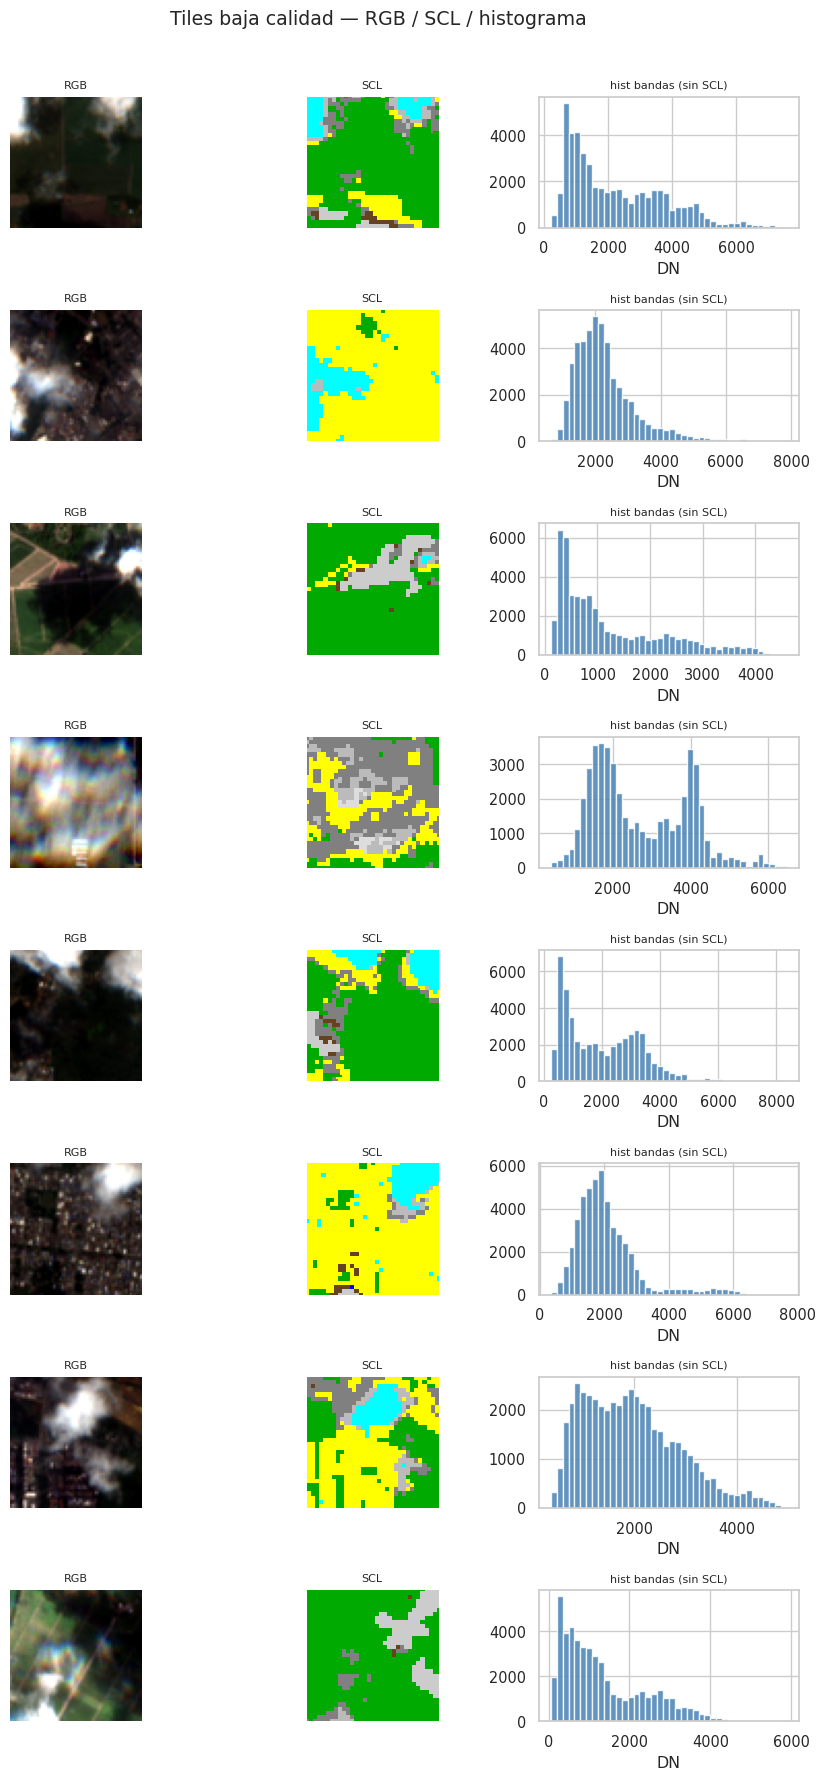

Guardado: /content/eda_sit2/06_panel_calidad_rgb_scl_hist.png


In [10]:
# @title EDA calidad — Paso 3: panel RGB + SCL + histograma
from matplotlib.colors import ListedColormap, BoundaryNorm

SCL_LABELS = {
    0: "nodata", 1: "saturado", 2: "sombra", 3: "nube", 4: "veg",
    5: "no_veg", 6: "agua", 7: "sin_clas", 8: "nube_med", 9: "cirrus",
    10: "nube_thin", 11: "nieve",
}
SCL_COLORS = [
    "#000000", "#ff0000", "#654321", "#cccccc", "#00aa00",
    "#ffff00", "#0000ff", "#808080", "#bbbbbb", "#00ffff",
    "#dddddd", "#ffffff",
]
_scl_cmap = ListedColormap(SCL_COLORS)
_scl_norm = BoundaryNorm(np.arange(-0.5, 12.5, 1), _scl_cmap.N)

def tile_scl_map(tile_13hw):
    idx_scl = _IDX_SCL if "_IDX_SCL" in dir() else BANDAS_S2.index("SCL")
    scl = np.rint(tile_13hw[idx_scl]).astype(np.int16)
    return scl

def plot_tile_panel(tile_13hw, title="", ax_rgb=None, ax_scl=None, ax_hist=None):
    if ax_rgb is not None:
        ax_rgb.imshow(tile_to_rgb_uint8(tile_13hw))
        ax_rgb.set_title("RGB", fontsize=8)
        ax_rgb.axis("off")
    if ax_scl is not None:
        scl = tile_scl_map(tile_13hw)
        im = ax_scl.imshow(scl, cmap=_scl_cmap, norm=_scl_norm, interpolation="nearest")
        ax_scl.set_title("SCL", fontsize=8)
        ax_scl.axis("off")
    if ax_hist is not None:
        vals = tile_13hw[:12].astype(np.float32).ravel()
        vals = vals[np.isfinite(vals)]
        ax_hist.hist(vals, bins=40, color="steelblue", alpha=0.85)
        ax_hist.set_title("hist bandas (sin SCL)", fontsize=8)
        ax_hist.set_xlabel("DN")
    if title and ax_rgb is not None:
        ax_rgb.set_ylabel(title, fontsize=7, rotation=0, labelpad=40, va="center")

_lista_path = EDA_DIR / "tiles_baja_calidad.csv"
if "lista" not in globals() and _lista_path.is_file():
    lista = pd.read_csv(_lista_path)
N_PANEL = min(8, len(lista)) if "lista" in globals() else 0
if N_PANEL == 0:
    print("Sin tiles en lista; ejecuta el Paso 2.")
else:
    fig, axes = plt.subplots(N_PANEL, 3, figsize=(9, 2.2 * N_PANEL))
    if N_PANEL == 1:
        axes = axes.reshape(1, -1)
    for r, (_, row) in enumerate(lista.head(N_PANEL).iterrows()):
        j = tile_zarr_index(row["tile_id"])
        tile = np.asarray(tiles_z[j])
        ttl = f"{row['tile_id'][:12]}… | {row['clase'][:12]}"
        plot_tile_panel(tile, ttl, axes[r, 0], axes[r, 1], axes[r, 2])
    plt.suptitle("Tiles baja calidad — RGB / SCL / histograma", y=1.01)
    plt.tight_layout()
    out_png = EDA_DIR / "06_panel_calidad_rgb_scl_hist.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardado:", out_png)



### Paso 4 — Reglas de calidad “estricta”

Criterio estricto (más exigente que el pipeline por defecto):
- `frac_nubes_scl` ≤ 0.15
- `frac_claros_scl` ≥ 0.90

Se reporta el % de tiles que pasan, global y por split.


In [11]:
# @title EDA calidad — Paso 4: % pasa filtro estricto
UMBRAL_NUBE_ESTRICTO = 0.15
UMBRAL_CLAROS_ESTRICTO = 0.90

df["_pasa_estricto"] = (
    (df["frac_nubes_scl"] <= UMBRAL_NUBE_ESTRICTO)
    & (df["frac_claros_scl"] >= UMBRAL_CLAROS_ESTRICTO)
)
pct_global = 100.0 * df["_pasa_estricto"].mean()
resumen_estricto = {"ambito": ["global"], "n": [len(df)], "pct_pasa_estricto": [pct_global]}
for sp, g in df.groupby("split"):
    resumen_estricto["ambito"].append(sp)
    resumen_estricto["n"].append(len(g))
    resumen_estricto["pct_pasa_estricto"].append(100.0 * g["_pasa_estricto"].mean())

tab_estricto = pd.DataFrame(resumen_estricto)
print(tab_estricto.round(2).to_string(index=False))
print(f"\nPipeline actual (ref.): nube≤0.30, claros≥0.10 → pasa {100*df['frac_nubes_scl'].le(0.30).mul(df['frac_claros_scl'].ge(0.10)).mean():.1f}%")
tab_estricto.to_csv(EDA_DIR / "pct_filtro_estricto.csv", index=False)
print("Guardado:", EDA_DIR / "pct_filtro_estricto.csv")


ambito    n  pct_pasa_estricto
global 2276              88.88
  test  342              86.26
 train 1593              89.01
   val  341              90.91

Pipeline actual (ref.): nube≤0.30, claros≥0.10 → pasa 100.0%
Guardado: /content/eda_sit2/pct_filtro_estricto.csv


## 2b. Estudio adicional del dataset (informe diagnóstico)

Complementa el EDA de calidad con los cinco analisis del informe:
data leakage temporal, auditoria texto vs visual, coherencia S5P-visual,
ozono alto vs bajo, y resumen exportable a CSV en `EDA_DIR`.


### Estudio A — Data leakage temporal (urgente)

El split es estratificado por **clase**, no por **fecha** ni **escena S2**.
Si la misma imagen satelital aporta tiles a train y val, el Recall puede estar inflado.
Salida: `leakage_temporal.csv`, `07_leakage_fechas.png`.


          par  fechas_compartidas  pct_fechas_solapadas_a  escenas_s2_compartidas  pct_escenas_solapadas_a  tiles_a  tiles_b
 train_vs_val                 150                   50.51                     171                    42.33     1593      341
train_vs_test                 155                   52.19                     180                    44.55     1593      342
  val_vs_test                 108                   65.45                     107                    53.77      341      342

Escenas S2 en train Y val: 171
Tiles afectados: 1533
img_id_s2                               split
20181223T153619_20181223T153614_T18NUJ  test      2
                                        train     1
                                        val       1
20181228T153611_20181228T153753_T18NUJ  test      1
                                        train     8
                                        val       1
20190102T153619_20190102T153616_T18NUJ  test      3
                                    

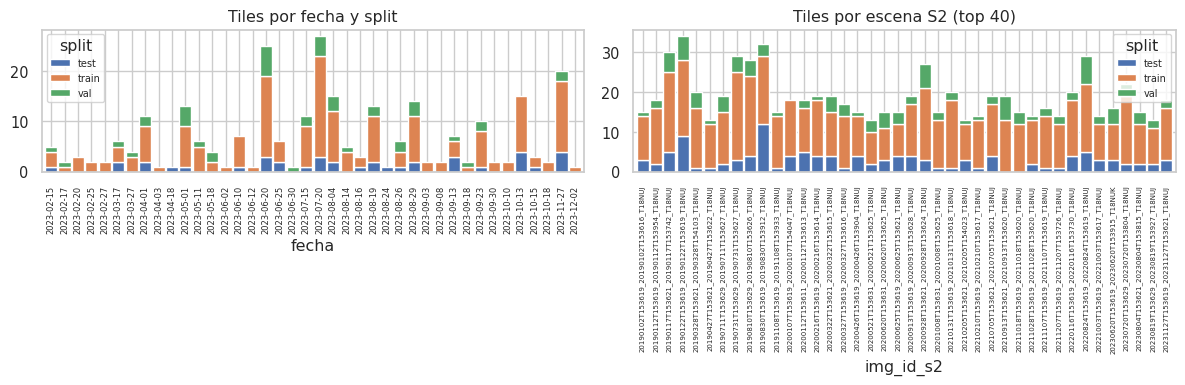

Guardado: /content/eda_sit2/leakage_temporal.csv | /content/eda_sit2/07_leakage_fechas.png


In [12]:
# @title Estudio A — leakage temporal (fechas y escenas S2)
import matplotlib.pyplot as plt

def _img_id_from_tile_id(tid: str) -> str:
    if "__y" in tid:
        return tid.split("__y")[0]
    return tid

work = df.copy()
if "img_id_s2" not in work.columns:
    work["img_id_s2"] = work["tile_id"].map(_img_id_from_tile_id)

rows_leak = []
for sp_a, sp_b in [("train", "val"), ("train", "test"), ("val", "test")]:
    fa = set(work.loc[work["split"] == sp_a, "fecha"].astype(str))
    fb = set(work.loc[work["split"] == sp_b, "fecha"].astype(str))
    fechas_sol = fa & fb
    ia = set(work.loc[work["split"] == sp_a, "img_id_s2"].astype(str))
    ib = set(work.loc[work["split"] == sp_b, "img_id_s2"].astype(str))
    escenas_sol = ia & ib
    n_a = int((work["split"] == sp_a).sum())
    n_b = int((work["split"] == sp_b).sum())
    rows_leak.append({
        "par": f"{sp_a}_vs_{sp_b}",
        "fechas_compartidas": len(fechas_sol),
        "pct_fechas_solapadas_a": 100 * len(fechas_sol) / max(1, len(fa)),
        "escenas_s2_compartidas": len(escenas_sol),
        "pct_escenas_solapadas_a": 100 * len(escenas_sol) / max(1, len(ia)),
        "tiles_a": n_a,
        "tiles_b": n_b,
    })

tab_leak = pd.DataFrame(rows_leak)
print(tab_leak.round(2).to_string(index=False))

# Tiles de la misma escena S2 en train Y val (caso mas grave)
train_esc = set(work.loc[work["split"] == "train", "img_id_s2"])
val_esc = set(work.loc[work["split"] == "val", "img_id_s2"])
esc_graves = sorted(train_esc & val_esc)
tiles_misma_escena = work[work["img_id_s2"].isin(esc_graves)].copy()
tiles_misma_escena = tiles_misma_escena.sort_values(["img_id_s2", "split"])
print(f"\nEscenas S2 en train Y val: {len(esc_graves)}")
print(f"Tiles afectados: {len(tiles_misma_escena)}")
if len(esc_graves) > 0:
    print(tiles_misma_escena.groupby(["img_id_s2", "split"]).size().head(12))

tab_leak.to_csv(EDA_DIR / "leakage_temporal.csv", index=False)
tiles_misma_escena.to_csv(EDA_DIR / "tiles_misma_escena_train_val.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [
    (axes[0], "fecha", "Tiles por fecha y split"),
    (axes[1], "img_id_s2", "Tiles por escena S2 (top 40)"),
]:
    if col == "fecha":
        ct = work.groupby(["fecha", "split"]).size().unstack(fill_value=0)
        ct.tail(40).plot(kind="bar", stacked=True, ax=ax, width=0.9)
        ax.tick_params(axis="x", rotation=90, labelsize=6)
    else:
        top_esc = work["img_id_s2"].value_counts().head(40).index
        sub = work[work["img_id_s2"].isin(top_esc)]
        ct = sub.groupby(["img_id_s2", "split"]).size().unstack(fill_value=0)
        ct.plot(kind="bar", stacked=True, ax=ax, width=0.9)
        ax.tick_params(axis="x", rotation=90, labelsize=5)
    ax.set_title(title)
    ax.legend(title="split", fontsize=7)
plt.tight_layout()
plt.savefig(EDA_DIR / "07_leakage_fechas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", EDA_DIR / "leakage_temporal.csv", "|", EDA_DIR / "07_leakage_fechas.png")


### Estudio B — Auditoria: 10 tiles por clase (texto vs visual)

Muestra RGB + fragmento de `descripcion` para revisar si la etiqueta coincide con lo visible.
Salida: `08_auditoria_10porclase.png`, `auditoria_texto_visual.csv`.


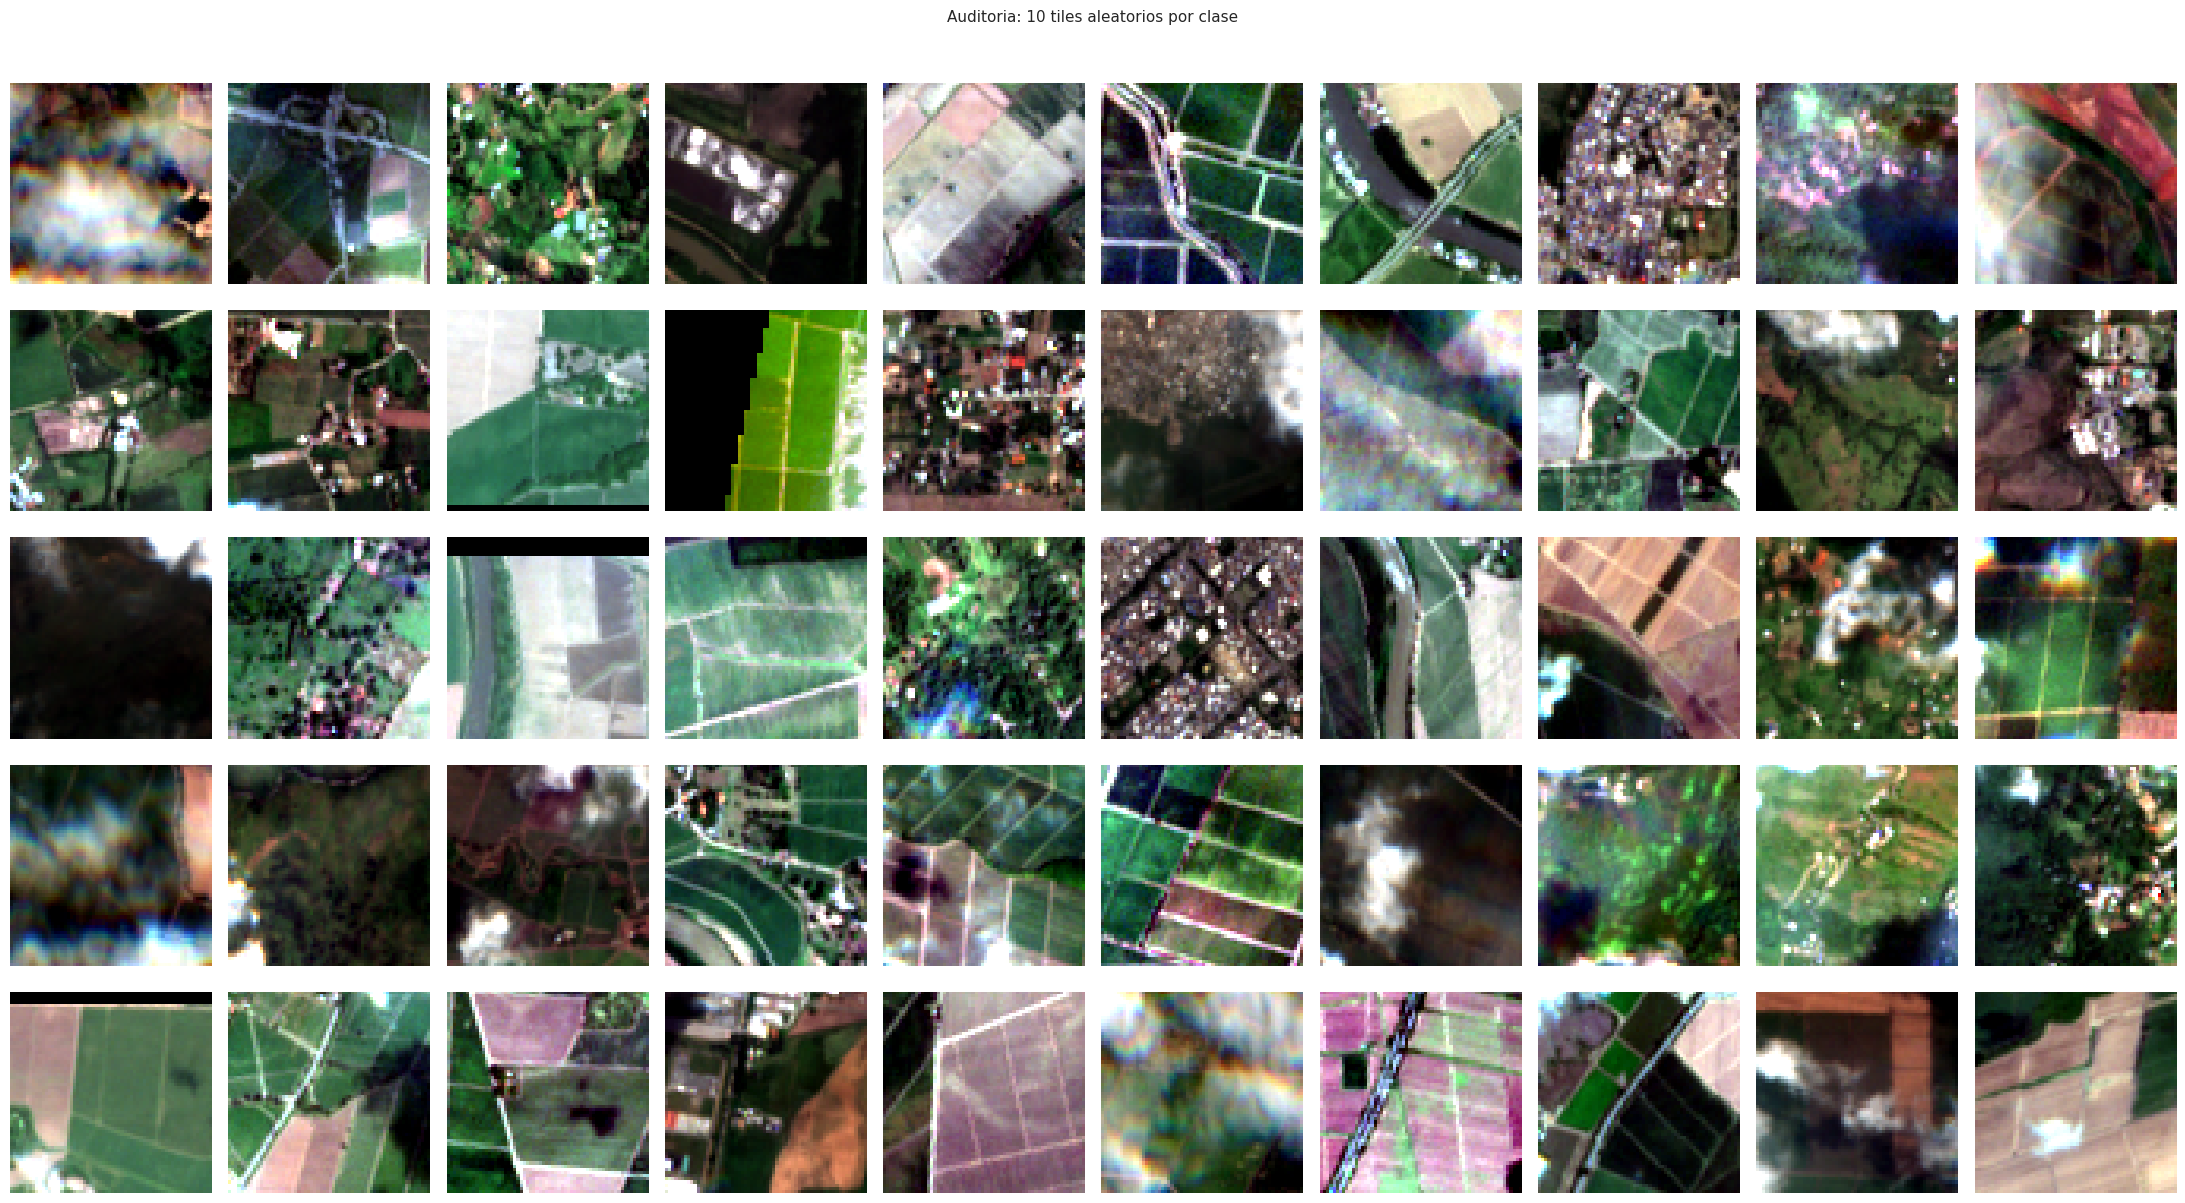

clase
contaminacion_alta_NO2    10
contaminacion_alta_SO2    10
ozono_anomalo             10
suelo_urbano              10
vegetacion_densa          10
dtype: int64

Guardado: /content/eda_sit2/auditoria_texto_visual.csv


In [13]:
# @title Estudio B — auditoria 10 tiles/clase (texto vs RGB)
rng_audit = np.random.default_rng(SEED)
N_AUDIT = 10
audit_rows = []

fig, axes = plt.subplots(len(CLASES), N_AUDIT, figsize=(2.2 * N_AUDIT, 2.4 * len(CLASES)))
if len(CLASES) == 1:
    axes = axes.reshape(1, -1)

for r, clase in enumerate(CLASES):
    sub = df[df["clase"] == clase]
    if len(sub) == 0:
        continue
    idxs = rng_audit.choice(sub.index.to_numpy(), size=min(N_AUDIT, len(sub)), replace=False)
    for c, j in enumerate(idxs):
        row = df.loc[j]
        tile = np.asarray(tiles_z[tile_zarr_index(row["tile_id"])])
        ax = axes[r, c]
        ax.imshow(tile_to_rgb_uint8(tile))
        ax.axis("off")
        if c == 0:
            ax.set_ylabel(clase.replace("contaminacion_", "").replace("_", "\n")[:18], fontsize=7)
        desc_short = str(row["descripcion"])[:55] + "..."
        audit_rows.append({
            "clase": clase,
            "tile_id": row["tile_id"],
            "split": row["split"],
            "frac_nubes": float(row["frac_nubes_scl"]),
            "ndvi": float(row["ndvi"]),
            "no2": float(row["no2"]),
            "descripcion_corta": desc_short,
        })

plt.suptitle("Auditoria: 10 tiles aleatorios por clase", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(EDA_DIR / "08_auditoria_10porclase.png", dpi=150, bbox_inches="tight")
plt.show()

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(EDA_DIR / "auditoria_texto_visual.csv", index=False)
print(audit_df.groupby("clase").size())
print("\nGuardado:", EDA_DIR / "auditoria_texto_visual.csv")


### Estudio C — Coherencia S5P vs visual

Cruza clase con valores NO2/SO2/O3 y NDVI. Detecta tiles **suelo_urbano** con NO2 alto
o **vegetacion** con contaminante extremo (posible desalineamiento grilla 3.5 km vs tile 640 m).
Salida: `coherencia_s5p_visual.csv`, scatter PNG.


Tiles sospechosos S5P-visual: 87 / 2276
motivo_sospecha
NO2_alto_pero_NDVI_alto    87
Name: count, dtype: int64


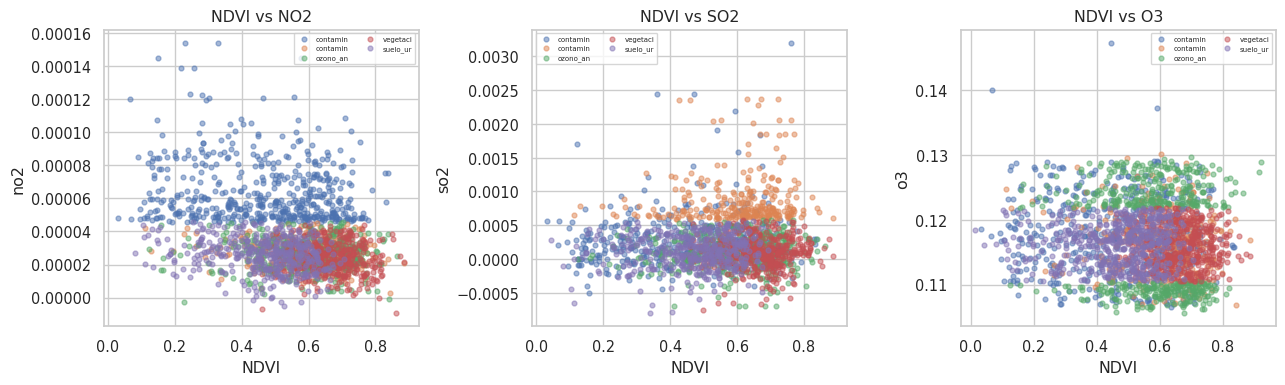

Guardado: /content/eda_sit2/coherencia_s5p_visual.csv


In [14]:
# @title Estudio C — coherencia S5P vs clase / NDVI
pct_path = DATA_DIR / "percentiles.json"
pct = json.loads(pct_path.read_text(encoding="utf-8")) if pct_path.is_file() else {}
p90_no2 = pct.get("NO2", {}).get("p90", np.nan)
p90_so2 = pct.get("SO2", {}).get("p90", np.nan)

work = df.copy()
work["no2_sobre_p90"] = work["no2"] >= p90_no2 if np.isfinite(p90_no2) else False
work["so2_sobre_p90"] = work["so2"] >= p90_so2 if np.isfinite(p90_so2) else False

# Casos sospechosos: etiqueta NO2 pero NDVI muy alto (bosque) o suelo_urbano sin NO2 alto
sospechosos = work[
    ((work["clase"] == "contaminacion_alta_NO2") & (work["ndvi"] > 0.65))
    | ((work["clase"] == "suelo_urbano") & (work["no2_sobre_p90"]))
    | ((work["clase"] == "vegetacion_densa") & (work["no2_sobre_p90"] | work["so2_sobre_p90"]))
].copy()
sospechosos["motivo_sospecha"] = np.select(
    [
        (sospechosos["clase"] == "contaminacion_alta_NO2") & (sospechosos["ndvi"] > 0.65),
        (sospechosos["clase"] == "suelo_urbano") & (sospechosos["no2_sobre_p90"]),
        (sospechosos["clase"] == "vegetacion_densa") & (sospechosos["no2_sobre_p90"]),
    ],
    ["NO2_alto_pero_NDVI_alto", "urbano_pero_NO2_p90", "veg_pero_NO2_p90"],
    default="otro",
)

print(f"Tiles sospechosos S5P-visual: {len(sospechosos)} / {len(work)}")
print(sospechosos["motivo_sospecha"].value_counts())
cols_s = ["tile_id", "split", "clase", "motivo_sospecha", "ndvi", "bsi", "no2", "so2", "o3", "frac_nubes_scl"]
sospechosos[cols_s].head(15).to_string(index=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, pol, col in zip(axes, ["NO2", "SO2", "O3"], ["no2", "so2", "o3"]):
    for clase in CLASES:
        sub = work[work["clase"] == clase]
        ax.scatter(sub["ndvi"], sub[col], s=12, alpha=0.5, label=clase[:8])
    ax.set_xlabel("NDVI")
    ax.set_ylabel(col)
    ax.set_title(f"NDVI vs {pol}")
    ax.legend(fontsize=5, ncol=2)
plt.tight_layout()
plt.savefig(EDA_DIR / "09_scatter_ndvi_contaminantes.png", dpi=150)
plt.show()

sospechosos.to_csv(EDA_DIR / "coherencia_s5p_visual.csv", index=False)
print("Guardado:", EDA_DIR / "coherencia_s5p_visual.csv")


### Estudio D — Ozono anomalo: alto (>=p90) vs bajo (<=p25)

El pipeline agrupa ambos en `ozono_anomalo` con el **mismo texto base**.
Aquí se separan usando `percentiles.json` y se comparan NDVI y fraccion de nubes.
Salida: `ozono_alto_vs_bajo.csv`, barras comparativas.


subtipo_ozono
ozono_ALTO_p90    282
ozono_BAJO_p25    218
Name: count, dtype: int64

Mediana NDVI / nubes por subtipo:
                  ndvi  frac_nubes_scl  frac_claros_scl
subtipo_ozono                                          
ozono_ALTO_p90  0.5856          0.0000           1.0000
ozono_BAJO_p25  0.6252          0.0073           0.9922

Ejemplo texto ALTO:
  Imagen satelital mostrando una densa y peligrosa acumulacion de ozono troposferico, indicando fuerte actividad fotoquimica. (2022-09-05, lat=3.3395, lon=-76.3912, NDVI=0.92, BSI=-0.17, NO2=nan, SO2=na

Ejemplo texto BAJO:
  Imagen satelital con niveles inusualmente bajos de ozono, sugiriendo alta nubosidad o dispersion de precursores. (2019-12-20, lat=3.5695, lon=-76.3079, NDVI=0.64, BSI=-0.23, NO2=nan, SO2=1.18e-04, O3=

>> Misma plantilla base; solo cambian numeros O3/NDVI.


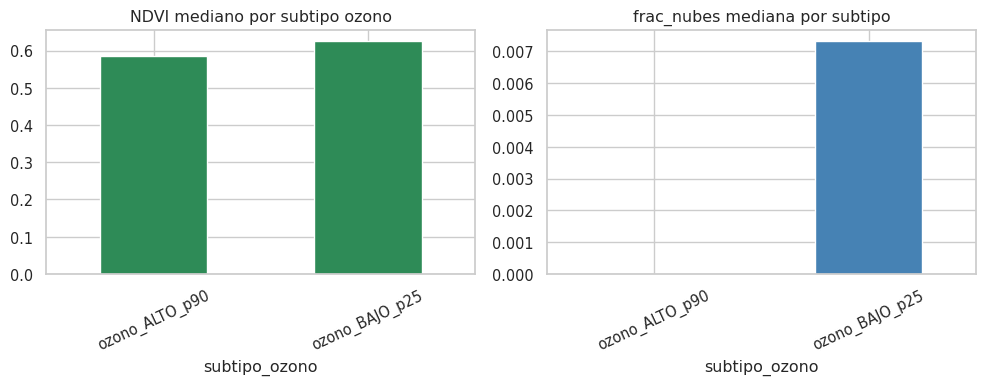

Guardado: /content/eda_sit2/ozono_alto_vs_bajo.csv


In [15]:
# @title Estudio D — ozono alto vs bajo (misma clase, textos identicos)
pct = json.loads((DATA_DIR / "percentiles.json").read_text(encoding="utf-8"))
p25_o3 = pct["O3"]["p25"]
p90_o3 = pct["O3"]["p90"]

oz = df[df["clase"] == "ozono_anomalo"].copy()
oz["subtipo_ozono"] = np.select(
    [oz["o3"] >= p90_o3, oz["o3"] <= p25_o3],
    ["ozono_ALTO_p90", "ozono_BAJO_p25"],
    default="ozono_intermedio",
)
print(oz["subtipo_ozono"].value_counts())
print("\nMediana NDVI / nubes por subtipo:")
print(oz.groupby("subtipo_ozono")[["ndvi", "frac_nubes_scl", "frac_claros_scl"]].median().round(4))

# Muestra que el texto es identico en estructura
ej_alto = oz[oz["subtipo_ozono"] == "ozono_ALTO_p90"].iloc[0]["descripcion"] if (oz["subtipo_ozono"] == "ozono_ALTO_p90").any() else ""
ej_bajo = oz[oz["subtipo_ozono"] == "ozono_BAJO_p25"].iloc[0]["descripcion"] if (oz["subtipo_ozono"] == "ozono_BAJO_p25").any() else ""
print("\nEjemplo texto ALTO:\n ", ej_alto[:200])
print("\nEjemplo texto BAJO:\n ", ej_bajo[:200])
print("\n>> Misma plantilla base; solo cambian numeros O3/NDVI.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
oz.groupby("subtipo_ozono")["ndvi"].median().plot(kind="bar", ax=axes[0], color="seagreen")
axes[0].set_title("NDVI mediano por subtipo ozono")
axes[0].tick_params(axis="x", rotation=25)
oz.groupby("subtipo_ozono")["frac_nubes_scl"].median().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("frac_nubes mediana por subtipo")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(EDA_DIR / "10_ozono_alto_vs_bajo.png", dpi=150)
plt.show()

oz_out = oz[["tile_id", "split", "o3", "subtipo_ozono", "ndvi", "descripcion"]]
oz_out.to_csv(EDA_DIR / "ozono_alto_vs_bajo.csv", index=False)
print("Guardado:", EDA_DIR / "ozono_alto_vs_bajo.csv")


### Resumen ejecutivo EDA + estudios

Tabla unica con hallazgos clave para el informe (copiar a `INFORME_DIAGNOSTICO_SIT2.md`).


In [16]:
# @title Resumen ejecutivo — hallazgos EDA
hallazgos = []

# Calidad estricta
if "_pasa_estricto" in df.columns:
    hallazgos.append({
        "tema": "filtro_estricto",
        "metrica": "pct_pasa_nube015_claros090",
        "valor": round(100 * df["_pasa_estricto"].mean(), 1),
        "nota": "Pipeline usa nube<=0.30, claros>=0.10",
    })

# Leakage
if Path(EDA_DIR / "leakage_temporal.csv").is_file():
    lk = pd.read_csv(EDA_DIR / "leakage_temporal.csv")
    row = lk[lk["par"] == "train_vs_val"].iloc[0]
    hallazgos.append({
        "tema": "leakage_temporal",
        "metrica": "escenas_s2_compartidas_train_val",
        "valor": int(row["escenas_s2_compartidas"]),
        "nota": f"fechas_compartidas={int(row['fechas_compartidas'])}",
    })

# Baja calidad
lista_path = EDA_DIR / "tiles_baja_calidad.csv"
if lista_path.is_file():
    hallazgos.append({
        "tema": "calidad_tiles",
        "metrica": "n_tiles_revisar",
        "valor": len(pd.read_csv(lista_path)),
        "nota": "top5pct nube + outliers NDVI",
    })

# Ozono
if Path(EDA_DIR / "ozono_alto_vs_bajo.csv").is_file():
    oz = pd.read_csv(EDA_DIR / "ozono_alto_vs_bajo.csv")
    hallazgos.append({
        "tema": "ozono_subtipos",
        "metrica": "n_ozono_ALTO_vs_BAJO",
        "valor": f"{(oz['subtipo_ozono']=='ozono_ALTO_p90').sum()}/{(oz['subtipo_ozono']=='ozono_BAJO_p25').sum()}",
        "nota": "mismo texto base en pipeline",
    })

# S5P
if Path(EDA_DIR / "coherencia_s5p_visual.csv").is_file():
    n = len(pd.read_csv(EDA_DIR / "coherencia_s5p_visual.csv"))
    hallazgos.append({
        "tema": "s5p_visual",
        "metrica": "n_tiles_sospechosos",
        "valor": n,
        "nota": "desalineamiento grilla 3.5km vs tile",
    })

resumen_eda = pd.DataFrame(hallazgos)
print(resumen_eda.to_string(index=False))
resumen_eda.to_csv(EDA_DIR / "resumen_hallazgos_eda.csv", index=False)
print("\nGuardado:", EDA_DIR / "resumen_hallazgos_eda.csv")
print("Todos los CSV/PNG en:", EDA_DIR)


            tema                          metrica   valor                                  nota
 filtro_estricto       pct_pasa_nube015_claros090    88.9 Pipeline usa nube<=0.30, claros>=0.10
leakage_temporal escenas_s2_compartidas_train_val     171                fechas_compartidas=150
   calidad_tiles                  n_tiles_revisar     146          top5pct nube + outliers NDVI
  ozono_subtipos             n_ozono_ALTO_vs_BAJO 282/218          mismo texto base en pipeline
      s5p_visual              n_tiles_sospechosos      87  desalineamiento grilla 3.5km vs tile

Guardado: /content/eda_sit2/resumen_hallazgos_eda.csv
Todos los CSV/PNG en: /content/eda_sit2


In [17]:
# @title Configuración entrenamiento
import math
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 32
NUM_EPOCHS = 60
EARLY_STOP_PATIENCE = 60
EARLY_STOP_MONITOR = "val/infonce"
VAL_CHECK_INTERVAL = 1.0
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 0.01
FREEZE_TEXT_EPOCHS = 1
FREEZE_VISUAL = True

# SAE: ReLU en encoder + L1 más fuerte (informe R-M1)
ALPHA_SAE = 0.1
ALPHA_SAE_WARMUP_EPOCHS = 5
LAMBDA_L1 = 1e-2

# Filtro calidad solo en train (informe R-M2)
TRAIN_MAX_FRAC_NUBES = 0.15
TRAIN_MIN_FRAC_CLAROS = 0.50

# Sampler balanceado: >= MIN_SAMPLES_PER_CLASS por clase en cada batch (R-M4)
MIN_SAMPLES_PER_CLASS = 4

# Descongelar ViT solo si Recall@1 val supera umbral (R-M6)
VIT_UNFREEZE_RECALL_THRESHOLD = 0.15
VIT_UNFREEZE_LAST_N_BLOCKS = 2
VIT_UNFREEZE_LR_MULT = 0.1

WANDB_PROJECT = "geovision-sit2-clip"
WANDB_RUN_NAME = "colab_clip_sae_train_v2"
USE_WANDB = True

os.environ.setdefault("WANDB_SILENT", "true")
os.environ.setdefault("WANDB_DISABLE_CODE", "true")

def setup_wandb():
    global USE_WANDB
    if not USE_WANDB:
        os.environ["WANDB_MODE"] = "disabled"
        print("WANDB desactivado (USE_WANDB=False)")
        return
    try:
        import wandb
    except ImportError:
        USE_WANDB = False
        os.environ["WANDB_MODE"] = "disabled"
        print("wandb no instalado; solo CSVLogger")
        return
    key = os.environ.get("WANDB_API_KEY")
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get("WANDB_API_KEY")
            os.environ["WANDB_API_KEY"] = key
        except Exception:
            pass
    if key:
        wandb.login(key=key, relogin=True)
        print("WANDB: login OK")
    else:
        os.environ["WANDB_MODE"] = "offline"
        print("WANDB: modo offline (sin API key). Secret WANDB_API_KEY o USE_WANDB=False")

setup_wandb()

METRICS_JSON = RUN_DIR / "metricas_por_epoca.json"
EMBEDDINGS_BEST = RUN_DIR / "embeddings_val_mejor.npz"
TEST_METRICS_JSON = RUN_DIR / "metricas_test.json"

KPI_RECALL1_MIN, KPI_RECALL1_EXC = 0.45, 0.65
KPI_RECALL5_MIN, KPI_RECALL5_EXC = 0.70, 0.85
KPI_SPARSITY_MIN, KPI_SPARSITY_EXC = 0.70, 0.85
KPI_MSE_SAE_MAX, KPI_MSE_SAE_EXC = 0.05, 0.02

_min_batch = MIN_SAMPLES_PER_CLASS * len(CLASES)
assert BATCH_SIZE >= _min_batch, (
    f"BATCH_SIZE={BATCH_SIZE} menor que {MIN_SAMPLES_PER_CLASS} x {len(CLASES)} clases = {_min_batch}"
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| batch:", BATCH_SIZE, "| epochs:", NUM_EPOCHS)
print(f"SAE: ReLU + lambda_l1={LAMBDA_L1} | alpha_sae=0 ep 0-{ALPHA_SAE_WARMUP_EPOCHS - 1} luego {ALPHA_SAE}")
print(f"Train filtro: nube<={TRAIN_MAX_FRAC_NUBES}, claros>={TRAIN_MIN_FRAC_CLAROS}")
print(f"Early stop: {EARLY_STOP_MONITOR} patience={EARLY_STOP_PATIENCE} | ViT unfreeze si recall@1>={VIT_UNFREEZE_RECALL_THRESHOLD}")
print("Metricas JSON:", METRICS_JSON)
if device == "cpu":
    print("AVISO: activa GPU en Colab (Runtime -> T4 GPU -> Reiniciar)")


WANDB: modo offline (sin API key). Secret WANDB_API_KEY o USE_WANDB=False
device: cuda | batch: 32 | epochs: 60
SAE: ReLU + lambda_l1=0.01 | alpha_sae=0 ep 0-4 luego 0.1
Train filtro: nube<=0.15, claros>=0.5
Early stop: val/infonce patience=60 | ViT unfreeze si recall@1>=0.15
Metricas JSON: /content/runs/sit2_clip_colab/metricas_por_epoca.json


In [18]:
# @title Métricas + SAE
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Sampler

@torch.no_grad()
def sparsity_ratio(z, threshold=0.01):
    return float((z.abs() < threshold).float().mean().item())

class SparseAutoencoder(nn.Module):
    def __init__(self, dim_in, dim_latent=512):
        super().__init__()
        self.encoder = nn.Linear(dim_in, dim_latent)
        self.decoder = nn.Linear(dim_latent, dim_in)

    def forward(self, x):
        z = F.relu(self.encoder(x))
        return self.decoder(z), z

def sae_loss(x, x_hat, z, lambda_l1=1e-3):
    mse = F.mse_loss(x_hat, x)
    l1 = z.abs().mean()
    return mse + lambda_l1 * l1, mse, l1

@torch.no_grad()
def recall_at_k_image_to_text(image_embeds, text_embeds, k=1):
    image_embeds = F.normalize(image_embeds, dim=-1)
    text_embeds = F.normalize(text_embeds, dim=-1)
    sim = image_embeds @ text_embeds.T
    labels = torch.arange(sim.shape[0], device=sim.device)
    kk = min(k, sim.shape[1])
    topk = sim.topk(kk, dim=1).indices
    return float((topk == labels.unsqueeze(1)).any(dim=1).float().mean().item())

@torch.no_grad()
def recall_at_k_prompt_ensemble(model, loader, device, k=1):
    model.eval()
    img_parts, txt_parts = [], []
    for batch in loader:
        tiles = batch["tile"].to(device)
        vi = model.encode_image(tiles)
        img_parts.append(vi["e"].cpu())
        ids, masks = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        vt = model.encode_text(ids, masks)
        txt_parts.append(vt["e"].cpu())
    if not img_parts:
        return 0.0
    return recall_at_k_image_to_text(torch.cat(img_parts, 0), torch.cat(txt_parts, 0), k)


In [19]:
# @title DataLoaders (13 bandas normalizadas + tokenizer)
from transformers import AutoTokenizer

try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

class Sit2TileDataset(Dataset):
    def __init__(
        self,
        frame,
        tiles_zarr,
        split,
        band_mean,
        band_std,
        tokenizer,
        max_length=256,
        quality_filter=False,
        max_frac_nubes=None,
        min_frac_claros=None,
    ):
        self.df = frame.reset_index(drop=True)
        mask = self.df["split"].values == split
        if quality_filter:
            if max_frac_nubes is not None:
                mask &= self.df["frac_nubes_scl"].values <= float(max_frac_nubes)
            if min_frac_claros is not None:
                mask &= self.df["frac_claros_scl"].values >= float(min_frac_claros)
        self._indices = np.nonzero(mask)[0].astype(np.int64)
        self.z = tiles_zarr
        self.mean = torch.as_tensor(band_mean, dtype=torch.float32).view(13, 1, 1)
        self.std = torch.as_tensor(band_std, dtype=torch.float32).view(13, 1, 1).clamp(min=1e-6)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return int(len(self._indices))

    def __getitem__(self, i):
        j = int(self._indices[i])
        row = self.df.iloc[j]
        tile = torch.from_numpy(np.asarray(self.z[j], dtype=np.float32))
        tile = (tile - self.mean) / self.std
        tok = self.tokenizer(
            str(row["descripcion"]), truncation=True, max_length=self.max_length,
            padding="max_length", return_tensors="pt",
        )
        return {
            "tile": tile,
            "input_ids": tok["input_ids"].squeeze(0),
            "attention_mask": tok["attention_mask"].squeeze(0),
            "tile_id": str(row["tile_id"]),
            "clase": str(row["clase"]),
        }

class BalancedClassBatchSampler(Sampler):
    """Cada batch incluye al menos min_per_class muestras por clase (con reemplazo si hace falta)."""

    def __init__(self, labels, batch_size, class_names, min_per_class=4, seed=SEED):
        self.batch_size = int(batch_size)
        self.min_per_class = int(min_per_class)
        self.class_names = list(class_names)
        self.rng = np.random.default_rng(seed)
        self.per_class = {}
        for c in self.class_names:
            idx = np.where(labels == c)[0]
            if idx.size == 0:
                raise ValueError(f"Sin muestras de clase {c} en train (revisa filtro de calidad)")
            self.per_class[c] = idx

    def __len__(self):
        return max(1, min(len(ix) for ix in self.per_class.values()) // self.min_per_class)

    def __iter__(self):
        pools = {c: self.rng.permutation(ix).tolist() for c, ix in self.per_class.items()}
        ptr = {c: 0 for c in self.class_names}

        def next_idx(c):
            if ptr[c] >= len(pools[c]):
                pools[c] = self.rng.permutation(self.per_class[c]).tolist()
                ptr[c] = 0
            i = pools[c][ptr[c]]
            ptr[c] += 1
            return int(i)

        for _ in range(len(self)):
            batch = []
            for c in self.class_names:
                for _ in range(self.min_per_class):
                    batch.append(next_idx(c))
            rest = self.batch_size - len(batch)
            if rest > 0:
                extras = self.rng.choice(self.class_names, size=rest, replace=True)
                for c in extras:
                    batch.append(next_idx(c))
            self.rng.shuffle(batch)
            yield batch

class Sit2SequenceDataset(Dataset):
    def __init__(self, frame, tiles_zarr, secuencias, band_mean, band_std, tokenizer, max_length=256):
        self.z = tiles_zarr
        self.seqs = secuencias
        self.mean = torch.as_tensor(band_mean, dtype=torch.float32).view(13, 1, 1)
        self.std = torch.as_tensor(band_std, dtype=torch.float32).view(13, 1, 1).clamp(min=1e-6)
        self.tokenizer = tokenizer
        self.max_length = max_length
        id2j = {str(r["tile_id"]): i for i, r in frame.reset_index(drop=True).iterrows()}
        self._valid = []
        for s in secuencias:
            js = [id2j.get(tid) for tid in s["tile_ids"]]
            if all(j is not None for j in js):
                self._valid.append((js, s["tile_ids"][-1], str(s["fechas"][-1])))

    def __len__(self):
        return len(self._valid)

    def __getitem__(self, i):
        js, last_tid, _ = self._valid[i]
        tiles = []
        for j in js:
            t = torch.from_numpy(np.asarray(self.z[int(j)], dtype=np.float32))
            tiles.append((t - self.mean) / self.std)
        tiles = torch.stack(tiles, dim=0)
        row = df[df["tile_id"] == last_tid].iloc[0]
        tok = self.tokenizer(
            str(row["descripcion"]), truncation=True, max_length=self.max_length,
            padding="max_length", return_tensors="pt",
        )
        return {
            "tiles_seq": tiles,
            "input_ids": tok["input_ids"].squeeze(0),
            "attention_mask": tok["attention_mask"].squeeze(0),
        }

def collate_sit2(batch):
    return {
        "tile": torch.stack([b["tile"] for b in batch]),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
    }

band_mean, band_std = compute_band_stats(ZARR_PATH)
text_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(text_name)

ds_train = Sit2TileDataset(
    df, tiles_z, "train", band_mean, band_std, tokenizer,
    quality_filter=True,
    max_frac_nubes=TRAIN_MAX_FRAC_NUBES,
    min_frac_claros=TRAIN_MIN_FRAC_CLAROS,
)
ds_val = Sit2TileDataset(df, tiles_z, "val", band_mean, band_std, tokenizer)
ds_test = Sit2TileDataset(df, tiles_z, "test", band_mean, band_std, tokenizer)
ds_seq = Sit2SequenceDataset(df, tiles_z, secuencias, band_mean, band_std, tokenizer)

n_train_raw = int((df["split"] == "train").sum())
print(f"Train: {len(ds_train)} (filtrado desde {n_train_raw}) | Val: {len(ds_val)} | Test: {len(ds_test)} | Secuencias: {len(ds_seq)}")
print(ds_train.df.iloc[ds_train._indices]["clase"].value_counts().reindex(CLASES).fillna(0).astype(int).to_string())

train_labels = ds_train.df.iloc[ds_train._indices]["clase"].values
train_batch_sampler = BalancedClassBatchSampler(
    train_labels, BATCH_SIZE, CLASES, min_per_class=MIN_SAMPLES_PER_CLASS, seed=SEED,
)

train_loader = DataLoader(
    ds_train,
    batch_sampler=train_batch_sampler,
    num_workers=NUM_WORKERS,
    collate_fn=collate_sit2,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    collate_fn=collate_sit2, pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    collate_fn=collate_sit2, pin_memory=torch.cuda.is_available(),
)


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Train: 1593 (filtrado desde 1593) | Val: 341 | Test: 342 | Secuencias: 30
clase
contaminacion_alta_NO2    350
contaminacion_alta_SO2    193
ozono_anomalo             350
vegetacion_densa          350
suelo_urbano              350


In [20]:
# @title Modelo GeoVision-CLIP + SAE
import open_clip
from huggingface_hub import hf_hub_download
from transformers import AutoModel

_CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
_CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

REMOTECLIP_HF_REPO = "chendelong/RemoteCLIP"
REMOTECLIP_MODEL_NAME = "ViT-B-32"
REMOTECLIP_CACHE_DIR = Path("/content/checkpoints")

def load_remoteclip_visual(model_name: str = REMOTECLIP_MODEL_NAME):
    REMOTECLIP_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
    ckpt_path = hf_hub_download(
        REMOTECLIP_HF_REPO,
        f"RemoteCLIP-{model_name}.pt",
        cache_dir=str(REMOTECLIP_CACHE_DIR),
        token=token,
    )
    print(f"{model_name} descargado en: {ckpt_path}")
    model, _, _ = open_clip.create_model_and_transforms(model_name)
    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    msg = model.load_state_dict(ckpt)
    print("load_state_dict:", msg)
    visual = model.visual
    print(f"OK: RemoteCLIP visual ({model_name}) listo.")
    return visual, ckpt_path

class GeoVisionClipSAEModel(nn.Module):
    def __init__(self, text_model_name=text_name, dim_latent_sae=512, dim_contrastive=256,
                 alpha_sae=ALPHA_SAE, lambda_l1=LAMBDA_L1, freeze_visual=FREEZE_VISUAL):
        super().__init__()
        self.alpha_sae = 0.0 if ALPHA_SAE_WARMUP_EPOCHS > 0 else float(alpha_sae)
        self.lambda_l1 = lambda_l1
        self.ms_adapter = nn.Conv2d(13, 3, 1, bias=True)
        self.visual, self.visual_pretrained_tag = load_remoteclip_visual(REMOTECLIP_MODEL_NAME)
        if freeze_visual:
            for p in self.visual.parameters():
                p.requires_grad = False
        dim_img = int(getattr(self.visual, "output_dim", 512))
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        dtxt = int(self.text_encoder.config.hidden_size)
        self.text_to_sae = nn.Linear(dtxt, dim_latent_sae)
        self.sae_img = SparseAutoencoder(dim_img, dim_latent_sae)
        self.sae_txt = SparseAutoencoder(dim_latent_sae, dim_latent_sae)
        self.proj_img = nn.Linear(dim_latent_sae, dim_contrastive)
        self.proj_txt = nn.Linear(dim_latent_sae, dim_contrastive)
        self.logit_scale = nn.Parameter(torch.ones([]) * math.log(1.0 / 0.07))
        self.register_buffer("clip_mean", torch.tensor(_CLIP_MEAN).view(1, 3, 1, 1), persistent=False)
        self.register_buffer("clip_std", torch.tensor(_CLIP_STD).view(1, 3, 1, 1), persistent=False)

    def unfreeze_visual_last_blocks(self, n_blocks: int = 2):
        if not hasattr(self.visual, "transformer"):
            print("AVISO: visual sin .transformer; no se descongeló ViT")
            return 0
        resblocks = self.visual.transformer.resblocks
        n = min(int(n_blocks), len(resblocks))
        for block in resblocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        for name in ("ln_post", "proj"):
            if hasattr(self.visual, name):
                for p in getattr(self.visual, name).parameters():
                    p.requires_grad = True
        n_train = sum(p.numel() for p in self.visual.parameters() if p.requires_grad)
        print(f"ViT: descongelados ultimos {n} bloques ({n_train:,} params entrenables en visual)")
        return n_train

    def encode_image(self, tiles):
        tiles = tiles.float()
        x3 = self.ms_adapter(tiles)
        x3 = F.interpolate(x3, (224, 224), mode="bicubic", align_corners=False)
        x3 = (x3 - self.clip_mean) / self.clip_std
        h = self.visual(x3)
        h_hat, z = self.sae_img(h)
        return {"h": h, "z": z, "h_hat": h_hat, "e": self.proj_img(z)}

    def encode_text(self, input_ids, attention_mask):
        out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        m = attention_mask.unsqueeze(-1).float()
        pooled = (out.last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-6)
        h = self.text_to_sae(pooled)
        h_hat, z = self.sae_txt(h)
        return {"h": h, "z": z, "h_hat": h_hat, "e": self.proj_txt(z)}

    def clip_infonce(self, e_img, e_txt):
        e_img = F.normalize(e_img, dim=-1)
        e_txt = F.normalize(e_txt, dim=-1)
        scale = self.logit_scale.exp().clamp(max=100.0)
        logits = scale * (e_img @ e_txt.T)
        t = torch.arange(logits.size(0), device=logits.device)
        return 0.5 * (F.cross_entropy(logits, t) + F.cross_entropy(logits.T, t))

    def forward(self, tiles, input_ids, attention_mask):
        vi = self.encode_image(tiles)
        vt = self.encode_text(input_ids, attention_mask)
        l_infonce = self.clip_infonce(vi["e"], vt["e"])
        li, msei, _ = sae_loss(vi["h"], vi["h_hat"], vi["z"], self.lambda_l1)
        lt, mset, _ = sae_loss(vt["h"], vt["h_hat"], vt["z"], self.lambda_l1)
        total = l_infonce + self.alpha_sae * (li + lt)
        return {
            "loss": total, "loss_infonce": l_infonce.detach(),
            "loss_sae_img": li.detach(), "loss_sae_txt": lt.detach(),
            "mse_sae_img": msei.detach(), "mse_sae_txt": mset.detach(),
            "z_img": vi["z"], "z_txt": vt["z"],
        }

    def set_text_trainable(self, trainable):
        for p in self.text_encoder.parameters():
            p.requires_grad = trainable
        for p in self.text_to_sae.parameters():
            p.requires_grad = trainable

class LitGeoVisionClipSAE(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = GeoVisionClipSAEModel()
        self._val_img, self._val_txt = [], []
        self._val_z_img, self._val_z_txt = [], []
        self._vit_unfrozen = False
        self._best_val_recall1 = 0.0

    def on_train_epoch_start(self):
        self.model.set_text_trainable(self.current_epoch >= FREEZE_TEXT_EPOCHS)
        if self.current_epoch < ALPHA_SAE_WARMUP_EPOCHS:
            self.model.alpha_sae = 0.0
        else:
            self.model.alpha_sae = float(ALPHA_SAE)

    def _maybe_unfreeze_vit(self):
        if self._vit_unfrozen or self._best_val_recall1 < VIT_UNFREEZE_RECALL_THRESHOLD:
            return
        self.model.unfreeze_visual_last_blocks(VIT_UNFREEZE_LAST_N_BLOCKS)
        self._vit_unfrozen = True
        opt = self.optimizers()
        if isinstance(opt, (list, tuple)):
            opt = opt[0]
        existing = {id(p) for g in opt.param_groups for p in g["params"]}
        new_params = [p for p in self.model.visual.parameters() if p.requires_grad and id(p) not in existing]
        if new_params:
            opt.add_param_group({"params": new_params, "lr": LR * VIT_UNFREEZE_LR_MULT})
            print(f"Optimizer: +{len(new_params)} tensores ViT con lr={LR * VIT_UNFREEZE_LR_MULT:.2e}")

    def training_step(self, batch, batch_idx):
        o = self.model(batch["tile"], batch["input_ids"], batch["attention_mask"])
        self.log("train/loss", o["loss"], prog_bar=True, on_step=False, on_epoch=True)
        self.log("train/infonce", o["loss_infonce"], on_epoch=True)
        self.log("train/alpha_sae", float(self.model.alpha_sae), on_epoch=True)
        self.log("train/mse_sae_img", o["mse_sae_img"], on_epoch=True)
        self.log("train/mse_sae_txt", o["mse_sae_txt"], on_epoch=True)
        self.log("train/sparsity_img", sparsity_ratio(o["z_img"]), on_epoch=True, prog_bar=True)
        self.log("train/sparsity_txt", sparsity_ratio(o["z_txt"]), on_epoch=True)
        return o["loss"]

    def on_validation_epoch_start(self):
        self._val_img.clear()
        self._val_txt.clear()
        self._val_z_img.clear()
        self._val_z_txt.clear()

    def validation_step(self, batch, batch_idx):
        o = self.model(batch["tile"], batch["input_ids"], batch["attention_mask"])
        self.log("val/loss", o["loss"], on_epoch=True, prog_bar=True)
        self.log("val/infonce", o["loss_infonce"], on_epoch=True)
        self.log("val/mse_sae_img", o["mse_sae_img"], on_epoch=True)
        self.log("val/mse_sae_txt", o["mse_sae_txt"], on_epoch=True)
        self.log("val/sparsity_img", sparsity_ratio(o["z_img"]), on_epoch=True, prog_bar=True)
        with torch.no_grad():
            vi = self.model.encode_image(batch["tile"])
            vt = self.model.encode_text(batch["input_ids"], batch["attention_mask"])
        self._val_img.append(vi["e"].detach().cpu())
        self._val_txt.append(vt["e"].detach().cpu())
        self._val_z_img.append(vi["z"].detach().cpu())
        self._val_z_txt.append(vt["z"].detach().cpu())

    def on_validation_epoch_end(self):
        if not self._val_img:
            return
        img = torch.cat(self._val_img, 0).to(self.device)
        txt = torch.cat(self._val_txt, 0).to(self.device)
        r1 = recall_at_k_image_to_text(img, txt, 1)
        r5 = recall_at_k_image_to_text(img, txt, 5)
        self.log("val/recall_at_1", r1, prog_bar=True, on_epoch=True)
        self.log("val/recall_at_5", r5, prog_bar=True, on_epoch=True)
        if r1 > self._best_val_recall1:
            self._best_val_recall1 = float(r1)
        self._maybe_unfreeze_vit()

    def configure_optimizers(self):
        params = [p for p in self.model.parameters() if p.requires_grad]
        opt = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS, eta_min=1e-6)
        return {
            "optimizer": opt,
            "lr_scheduler": {"scheduler": sched, "interval": "epoch"},
        }


In [21]:
# @title Entrenamiento + validación (una sola corrida)
import json
import sys
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping, TQDMProgressBar
try:
    from lightning.pytorch.utilities.rank_zero import rank_zero_info
except ImportError:
    from pytorch_lightning.utilities.rank_zero import rank_zero_info

def _scalar(v):
    if hasattr(v, "item"):
        return float(v.item())
    return float(v)

def _kpi_flag(val, min_ok=None, max_ok=None, exc=None):
    if val is None:
        return "n/a"
    if min_ok is not None and val < min_ok:
        return "FAIL"
    if max_ok is not None and val > max_ok:
        return "FAIL"
    if exc is not None and val >= exc:
        return "EXC"
    if min_ok is not None and val >= min_ok:
        return "OK"
    if max_ok is not None and val <= max_ok:
        return "OK"
    return "parcial"

class EpochMetricsJsonCallback(pl.Callback):
    def __init__(self, json_path, embeddings_path, val_tile_ids):
        self.json_path = Path(json_path)
        self.embeddings_path = Path(embeddings_path)
        self.val_tile_ids = list(val_tile_ids)
        self.history = {"kpi_umbrales": {
            "recall_at_1_min": KPI_RECALL1_MIN, "recall_at_1_exc": KPI_RECALL1_EXC,
            "recall_at_5_min": KPI_RECALL5_MIN, "recall_at_5_exc": KPI_RECALL5_EXC,
            "sparsity_min": KPI_SPARSITY_MIN, "mse_sae_max": KPI_MSE_SAE_MAX,
        }, "epochs": [], "best": None}
        self._best_r1 = -1.0

    def _flush_json(self):
        self.json_path.parent.mkdir(parents=True, exist_ok=True)
        self.json_path.write_text(json.dumps(self.history, indent=2, ensure_ascii=False), encoding="utf-8")

    def on_train_epoch_end(self, trainer, pl_module):
        ep = int(trainer.current_epoch)
        m = {k: _scalar(v) for k, v in trainer.callback_metrics.items() if not k.startswith("_")}
        row = {"epoch": ep}
        for key in (
            "train/loss", "train/infonce", "train/alpha_sae", "train/mse_sae_img", "train/mse_sae_txt",
            "train/sparsity_img", "train/sparsity_txt",
            "val/loss", "val/infonce", "val/mse_sae_img", "val/mse_sae_txt",
            "val/sparsity_img", "val/recall_at_1", "val/recall_at_5",
        ):
            if key in m:
                row[key] = round(m[key], 6)
        self.history["epochs"].append(row)
        r1 = row.get("val/recall_at_1")
        r5 = row.get("val/recall_at_5")
        sp = row.get("val/sparsity_img")
        mse = row.get("val/mse_sae_img")
        improved = r1 is not None and r1 > self._best_r1
        if improved:
            self._best_r1 = r1
            self.history["best"] = dict(row)
            if pl_module._val_img:
                np.savez_compressed(
                    self.embeddings_path,
                    e_img=torch.cat(pl_module._val_img, 0).numpy(),
                    e_txt=torch.cat(pl_module._val_txt, 0).numpy(),
                    z_img=torch.cat(pl_module._val_z_img, 0).numpy(),
                    z_txt=torch.cat(pl_module._val_z_txt, 0).numpy(),
                    tile_ids=np.array(self.val_tile_ids, dtype=object),
                    epoch=ep,
                )
        self._flush_json()
        lines = [
            "", "=" * 60, f"Época {ep:03d}", "=" * 60,
            f"  train/loss = {row.get('train/loss', '—')}",
            f"  val/loss   = {row.get('val/loss', '—')}",
            f"  val/infonce= {row.get('val/infonce', '—')}",
            f"  alpha_sae  = {row.get('train/alpha_sae', '—')}",
            f"  val/recall@1 = {r1}  [{_kpi_flag(r1, min_ok=KPI_RECALL1_MIN, exc=KPI_RECALL1_EXC)}]",
            f"  val/recall@5 = {r5}  [{_kpi_flag(r5, min_ok=KPI_RECALL5_MIN, exc=KPI_RECALL5_EXC)}]",
            f"  val/sparsity = {sp}  [{_kpi_flag(sp, min_ok=KPI_SPARSITY_MIN)}]",
            f"  val/mse_sae  = {mse}  [{_kpi_flag(mse, max_ok=KPI_MSE_SAE_MAX)}]",
        ]
        if improved:
            lines.append(f"  >> mejor recall@1 -> {self.embeddings_path.name}")
        rank_zero_info("\n".join(lines))
        sys.stdout.flush()

csv_logger = pl.loggers.CSVLogger(save_dir=str(RUN_DIR), name="metrics")
loggers = [csv_logger]
if USE_WANDB and os.environ.get("WANDB_API_KEY"):
    loggers.insert(0, WandbLogger(project=WANDB_PROJECT, name=WANDB_RUN_NAME, save_dir=str(RUN_DIR)))
else:
    print("WANDB omitido; metricas en", RUN_DIR)

val_tile_ids = df.loc[df["split"] == "val", "tile_id"].astype(str).tolist()
metrics_cb = EpochMetricsJsonCallback(METRICS_JSON, EMBEDDINGS_BEST, val_tile_ids)
ckpt_cb = ModelCheckpoint(
    dirpath=str(RUN_DIR / "checkpoints"),
    filename="best-{epoch:02d}-r1{val/recall_at_1:.3f}",
    monitor="val/recall_at_1", mode="max", save_top_k=1,
)
early_cb = EarlyStopping(
    monitor=EARLY_STOP_MONITOR, mode="min", patience=EARLY_STOP_PATIENCE, verbose=True,
)

if not torch.cuda.is_available():
    raise RuntimeError("GPU no detectada. Colab: Runtime -> T4 GPU -> Reiniciar.")

lit = LitGeoVisionClipSAE()
trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="gpu",
    devices=1,
    logger=loggers,
    callbacks=[ckpt_cb, early_cb, metrics_cb, TQDMProgressBar(refresh_rate=10), LearningRateMonitor(logging_interval="epoch")],
    default_root_dir=str(RUN_DIR),
    log_every_n_steps=10,
    val_check_interval=VAL_CHECK_INTERVAL,
    enable_progress_bar=True,
    enable_model_summary=False,
)
trainer.fit(lit, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("\nEntrenamiento terminado.")
print("Mejor checkpoint:", ckpt_cb.best_model_path)
print("Historial JSON:", METRICS_JSON)
print("Embeddings val:", EMBEDDINGS_BEST)
if getattr(lit, "_vit_unfrozen", False):
    print("ViT: ultimos bloques descongelados durante el entrenamiento")
else:
    print(f"ViT: sigue congelado (recall@1 no alcanzo {VIT_UNFREEZE_RECALL_THRESHOLD})")
if USE_WANDB:
    import wandb
    wandb.finish()


WANDB omitido; metricas en /content/runs/sit2_clip_colab


RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

ViT-B-32 descargado en: /content/checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


load_state_dict: <All keys matched successfully>
OK: RemoteCLIP visual (ViT-B-32) listo.


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]


Época 058
  train/loss = 0.011984
  val/loss   = 2.855208
  val/infonce= 2.853466
  alpha_sae  = 0.1
  val/recall@1 = 0.067449  [FAIL]
  val/recall@5 = 0.217009  [FAIL]
  val/sparsity = 0.504078  [FAIL]
  val/mse_sae  = 0.008479  [OK]


Validation: |          | 0/? [00:00<?, ?it/s]


Época 059
  train/loss = 0.011627
  val/loss   = 2.856137
  val/infonce= 2.854396
  alpha_sae  = 0.1
  val/recall@1 = 0.064516  [FAIL]
  val/recall@5 = 0.219941  [FAIL]
  val/sparsity = 0.504021  [FAIL]
  val/mse_sae  = 0.008469  [OK]
`Trainer.fit` stopped: `max_epochs=60` reached.



Entrenamiento terminado.
Mejor checkpoint: /content/runs/sit2_clip_colab/checkpoints/best-epoch=11-r1val/recall_at_1=0.082.ckpt
Historial JSON: /content/runs/sit2_clip_colab/metricas_por_epoca.json
Embeddings val: /content/runs/sit2_clip_colab/embeddings_val_mejor.npz
ViT: sigue congelado (recall@1 no alcanzo 0.15)


## 3. Diagnóstico post-entrenamiento

Análisis tras `trainer.fit`: curvas desde `metricas_por_epoca.json`, Recall global vs por clase,
histograma de `z_img`, inspección de peores pares y notas de ablación (α, λ).

**Requisito:** haber ejecutado la celda de entrenamiento (y preferiblemente tener `embeddings_val_mejor.npz`).


### Curvas de validación desde JSON

Lee `RUN_DIR/metricas_por_epoca.json` y grafica Recall@1/@5, InfoNCE val, sparsity y MSE SAE imagen.


Mejor época (JSON): {'epoch': 11, 'train/loss': 0.367262, 'train/infonce': 0.361134, 'train/alpha_sae': 0.1, 'train/mse_sae_img': 0.044357, 'train/mse_sae_txt': 0.015568, 'train/sparsity_img': 0.519135, 'train/sparsity_txt': 0.571692, 'val/loss': 2.208782, 'val/infonce': 2.202922, 'val/mse_sae_img': 0.042116, 'val/mse_sae_txt': 0.015133, 'val/sparsity_img': 0.522212, 'val/recall_at_1': 0.082111, 'val/recall_at_5': 0.252199}
 epoch  val/recall_at_1  val/recall_at_5  val/loss  train/loss  val/infonce  val/sparsity_img  val/mse_sae_img
     0           0.0029           0.0293    3.2523      3.3365       3.2523            0.4872           0.1728
     1           0.0235           0.0997    2.7664      3.1492       2.7664            0.4874           0.1725
     2           0.0440           0.1584    2.3603      2.4958       2.3603            0.4973           0.1719
     3           0.0616           0.1730    2.2125      1.9682       2.2125            0.5045           0.1714
     4           

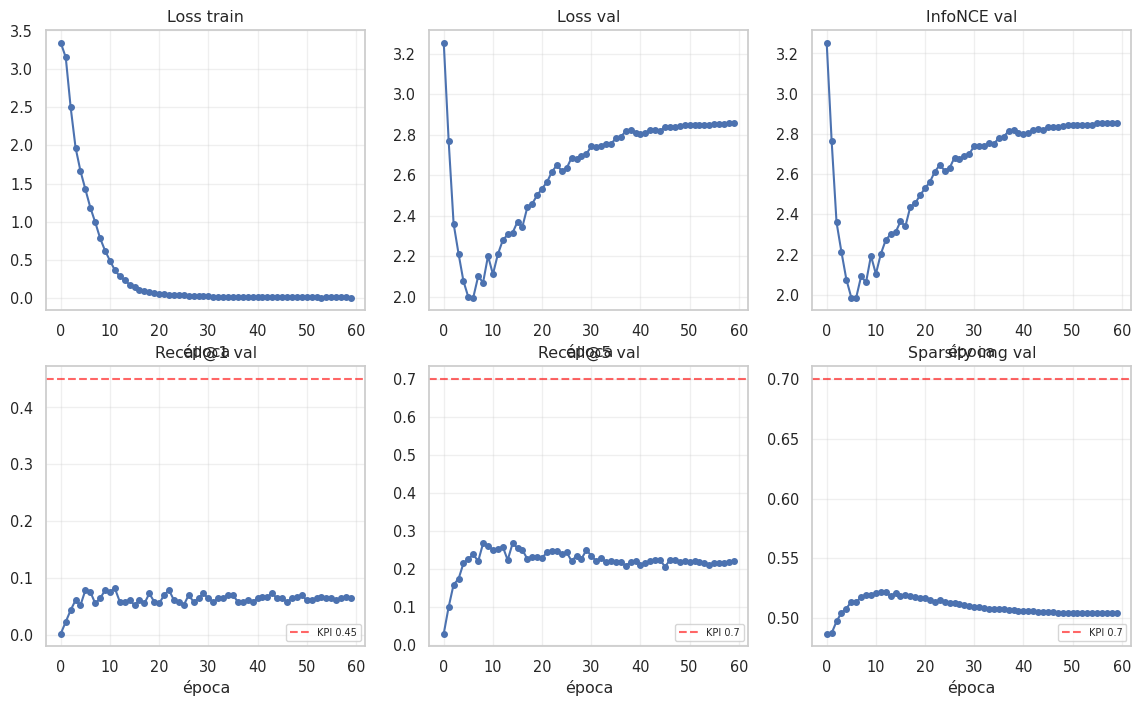

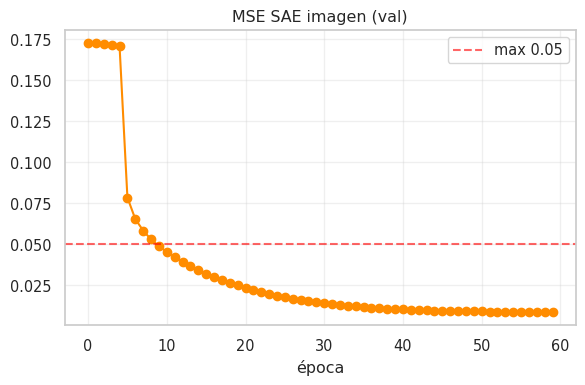

Guardado: /content/runs/sit2_clip_colab/curvas_diagnostico_val.png | /content/runs/sit2_clip_colab/curva_mse_sae_val.png


In [22]:
# @title Diagnóstico — curvas val (recall, infonce, sparsity, MSE)
import json
import matplotlib.pyplot as plt

def _col_train_loss(dfm):
    if "train/loss" in dfm.columns:
        return "train/loss"
    if "train/loss_epoch" in dfm.columns:
        return "train/loss_epoch"
    return None

hist = json.loads(Path(METRICS_JSON).read_text(encoding="utf-8"))
rows = hist.get("epochs", [])
if not rows:
    raise ValueError(f"No hay épocas en {METRICS_JSON}. Ejecuta primero el entrenamiento.")

dfm = pd.DataFrame(rows)
col_tl = _col_train_loss(dfm)
print("Mejor época (JSON):", hist.get("best"))
cols_show = ["epoch", "val/recall_at_1", "val/recall_at_5", "val/loss", "val/infonce",
             "val/sparsity_img", "val/mse_sae_img"]
if col_tl:
    cols_show.insert(4, col_tl)
cols_show = [c for c in cols_show if c in dfm.columns]
print(dfm[cols_show].round(4).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_specs = [
    (axes[0, 0], col_tl, "Loss train"),
    (axes[0, 1], "val/loss", "Loss val"),
    (axes[0, 2], "val/infonce", "InfoNCE val"),
    (axes[1, 0], "val/recall_at_1", "Recall@1 val", KPI_RECALL1_MIN),
    (axes[1, 1], "val/recall_at_5", "Recall@5 val", KPI_RECALL5_MIN),
    (axes[1, 2], "val/sparsity_img", "Sparsity img val", KPI_SPARSITY_MIN),
]
for ax, col, title, *kpi in plot_specs:
    if col and col in dfm.columns:
        ax.plot(dfm["epoch"], dfm[col], "o-", ms=4, lw=1.5)
    if kpi:
        ax.axhline(kpi[0], color="red", ls="--", alpha=0.6, label=f"KPI {kpi[0]}")
        ax.legend(fontsize=7)
    ax.set_title(title)
    ax.set_xlabel("época")
    ax.grid(True, alpha=0.3)

fig2, ax2 = plt.subplots(figsize=(6, 4))
if "val/mse_sae_img" in dfm.columns:
    ax2.plot(dfm["epoch"], dfm["val/mse_sae_img"], "o-", color="darkorange", lw=1.5)
    ax2.axhline(KPI_MSE_SAE_MAX, color="red", ls="--", alpha=0.6, label=f"max {KPI_MSE_SAE_MAX}")
    ax2.legend()
ax2.set_title("MSE SAE imagen (val)")
ax2.set_xlabel("época")
ax2.grid(True, alpha=0.3)
plt.tight_layout()

out_png = RUN_DIR / "curvas_diagnostico_val.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
fig2.savefig(RUN_DIR / "curva_mse_sae_val.png", dpi=150)
plt.show()
print("Guardado:", out_png, "|", RUN_DIR / "curva_mse_sae_val.png")


### Recall@1 global vs misma clase + matriz de confusión

- **Global:** texto correcto entre todos los de val (protocolo consigna).
- **Misma clase:** el texto correcto solo compite con textos de la **misma** clase (diagnóstico: ¿el modelo distingue clase o solo parecidos globales?).

Usa `embeddings_val_mejor.npz` del mejor Recall@1.


Recall@1 global (val, n=341): 0.0821
Recall@5 global:                  0.2522
Recall@1 misma clase (promedio):  0.0416  (por clase con n>=2)
  → Si misma clase >> global: textos muy parecidos entre clases.

Matriz confusión (clase verdadera × predicha por similitud img→txt):
predicha_top1           contaminacion_alta_NO2  contaminacion_alta_SO2  \
verdadera                                                                
contaminacion_alta_NO2                      33                       5   
contaminacion_alta_SO2                       2                       6   
ozono_anomalo                               12                       9   
vegetacion_densa                             9                       8   
suelo_urbano                                15                       2   

predicha_top1           ozono_anomalo  vegetacion_densa  suelo_urbano  
verdadera                                                              
contaminacion_alta_NO2              5                13      

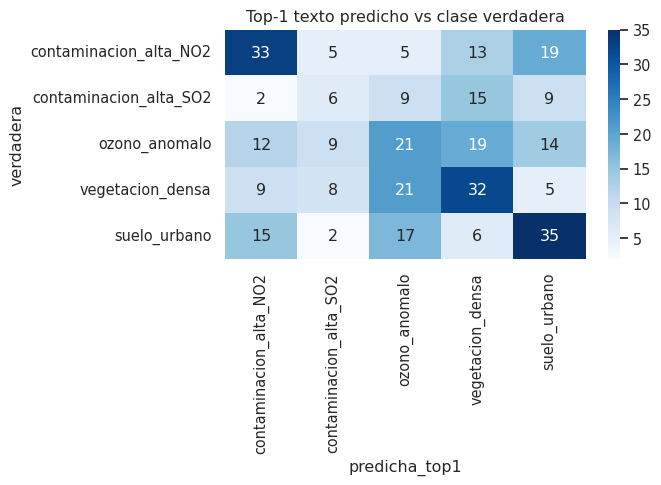

Guardado: /content/runs/sit2_clip_colab/matriz_confusion_clase.png | /content/runs/sit2_clip_colab/recall_global_vs_clase.csv


In [23]:
# @title Diagnóstico — Recall global vs misma clase + matriz confusión
import torch.nn.functional as F

def recall_at_k_masked(e_img, e_txt, k=1, mask=None):
    e_img = F.normalize(torch.as_tensor(e_img), dim=-1)
    e_txt = F.normalize(torch.as_tensor(e_txt), dim=-1)
    sim = e_img @ e_txt.T
    n = sim.shape[0]
    labels = torch.arange(n)
    if mask is not None:
        sim = sim.masked_fill(~mask, float("-inf"))
    kk = min(k, sim.shape[1])
    topk = sim.topk(kk, dim=1).indices
    return float((topk == labels.unsqueeze(1)).any(dim=1).float().mean().item())

def confusion_top1(e_img, e_txt, clases):
    e_img = F.normalize(torch.as_tensor(e_img), dim=-1)
    e_txt = F.normalize(torch.as_tensor(e_txt), dim=-1)
    pred_idx = (e_img @ e_txt.T).argmax(dim=1).numpy()
    pred_clase = [clases[int(j)] for j in pred_idx]
    mat = pd.crosstab(
        pd.Categorical(clases, categories=CLASES, ordered=True),
        pd.Categorical(pred_clase, categories=CLASES, ordered=True),
        rownames=["verdadera"], colnames=["predicha_top1"],
    ).reindex(index=CLASES, columns=CLASES, fill_value=0)
    return mat

emb_path = Path(EMBEDDINGS_BEST)
if not emb_path.is_file():
    raise FileNotFoundError(f"No existe {emb_path}. Entrena primero o ajusta EMBEDDINGS_BEST.")

emb = np.load(emb_path, allow_pickle=True)
e_img, e_txt = emb["e_img"], emb["e_txt"]
tile_ids = emb["tile_ids"].astype(str)
id2clase = df.set_index("tile_id")["clase"].to_dict()
clases_val = np.array([id2clase.get(tid, "") for tid in tile_ids])

r1_global = recall_at_k_image_to_text(torch.from_numpy(e_img), torch.from_numpy(e_txt), 1)
r5_global = recall_at_k_image_to_text(torch.from_numpy(e_img), torch.from_numpy(e_txt), 5)

r1_cls, n_eval = [], 0
clases_t = torch.as_tensor([CLASES.index(c) if c in CLASES else -1 for c in clases_val])
for ci, cname in enumerate(CLASES):
    idx = torch.where(clases_t == ci)[0]
    if len(idx) < 2:
        continue
    mask = torch.zeros(len(clases_val), len(clases_val), dtype=torch.bool)
    for i in idx:
        mask[i, idx] = True
    r1_cls.append(recall_at_k_masked(e_img, e_txt, 1, mask))
    n_eval += len(idx)
r1_misma_clase = float(np.mean(r1_cls)) if r1_cls else float("nan")

print(f"Recall@1 global (val, n={len(tile_ids)}): {r1_global:.4f}")
print(f"Recall@5 global:                  {r5_global:.4f}")
print(f"Recall@1 misma clase (promedio):  {r1_misma_clase:.4f}  (por clase con n>=2)")
print(f"  → Si misma clase >> global: textos muy parecidos entre clases.")

cm = confusion_top1(e_img, e_txt, clases_val)
print("\nMatriz confusión (clase verdadera × predicha por similitud img→txt):")
print(cm)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Top-1 texto predicho vs clase verdadera")
plt.tight_layout()
out_cm = RUN_DIR / "matriz_confusion_clase.png"
plt.savefig(out_cm, dpi=150)
plt.show()
pd.DataFrame({
    "metrica": ["recall_at_1_global", "recall_at_5_global", "recall_at_1_misma_clase"],
    "valor": [r1_global, r5_global, r1_misma_clase],
}).to_csv(RUN_DIR / "recall_global_vs_clase.csv", index=False)
print("Guardado:", out_cm, "|", RUN_DIR / "recall_global_vs_clase.csv")


### Histograma de `z_img` (val, mejor checkpoint)

Distribución de activaciones del SAE visual. Si casi no hay masa cerca de 0, subir λ no alcanzará sparsity 0.70 sin ReLU/top-k.


|z| < 0.01: 0.5222  (KPI sparsity ≈ 52.22%, meta ≥ 0.7)
z: mean=0.0710 std=0.1005 min=0.0000 max=0.6837


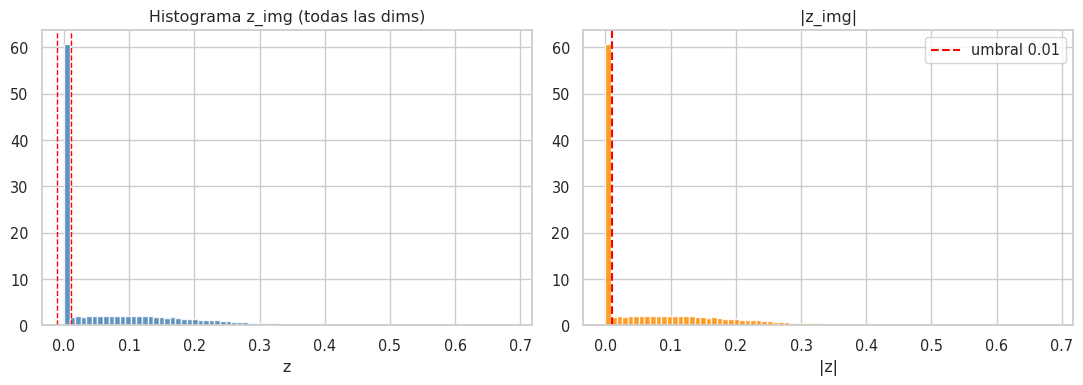

  λ=1e-04 → sparsity actual ~0.522 (subir λ empuja |z|→0 solo si re-entrenas)
  λ=1e-03 → sparsity actual ~0.522 (subir λ empuja |z|→0 solo si re-entrenas)
  λ=1e-02 → sparsity actual ~0.522 (subir λ empuja |z|→0 solo si re-entrenas)
  λ=1e-01 → sparsity actual ~0.522 (subir λ empuja |z|→0 solo si re-entrenas)
Guardado: /content/runs/sit2_clip_colab/histograma_z_img_val.png


In [24]:
# @title Diagnóstico — histograma z_img (val)
emb = np.load(EMBEDDINGS_BEST, allow_pickle=True)
z = emb["z_img"].astype(np.float64).ravel()
thr = 0.01
frac_below = float((np.abs(z) < thr).mean())
print(f"|z| < {thr}: {frac_below:.4f}  (KPI sparsity ≈ {frac_below:.2%}, meta ≥ {KPI_SPARSITY_MIN})")
print(f"z: mean={z.mean():.4f} std={z.std():.4f} min={z.min():.4f} max={z.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(z, bins=80, color="steelblue", alpha=0.85, density=True)
axes[0].axvline(-thr, color="red", ls="--", lw=1)
axes[0].axvline(thr, color="red", ls="--", lw=1)
axes[0].set_title("Histograma z_img (todas las dims)")
axes[0].set_xlabel("z")

axes[1].hist(np.abs(z), bins=80, color="darkorange", alpha=0.85, density=True)
axes[1].axvline(thr, color="red", ls="--", label=f"umbral {thr}")
axes[1].set_title("|z_img|")
axes[1].set_xlabel("|z|")
axes[1].legend()
plt.tight_layout()
out_h = RUN_DIR / "histograma_z_img_val.png"
plt.savefig(out_h, dpi=150)
plt.show()

# Porcentaje bajo umbral vs lambda (teórico, sin re-entrenar)
for lam in [1e-4, 1e-3, 1e-2, 1e-1]:
    print(f"  λ={lam:.0e} → sparsity actual ~{frac_below:.3f} (subir λ empuja |z|→0 solo si re-entrenas)")

print("Guardado:", out_h)


### 20 tiles con peor similitud imagen → su texto correcto

Ordenados por coseno entre `e_img[i]` y `e_txt[i]`. Ayuda a separar **error de dato** (nube, NDVI raro) vs **error de modelo**.


 rank                                              tile_id  cos_diag                  clase  frac_nubes_scl  frac_claros_scl     ndvi                                                                                                               descripcion
    1 20190711T153629_20190711T153627_T18NUJ__y3072__x2144 -0.091517       vegetacion_densa        0.124756         0.875244 0.608896 Imagen satelital de una extensa area verde o bosque urbano, con abundante vegetacion densa y aire relativamente limpio. …
    2 20220116T153619_20220116T153730_T18NUJ__y1472__x3200 -0.051623          ozono_anomalo        0.004883         0.995117 0.638703 Imagen satelital con niveles inusualmente bajos de ozono, sugiriendo alta nubosidad o dispersion de precursores. (2022-0…
    3 20220426T153609_20220426T153612_T18NUK__y0064__x2208 -0.006309           suelo_urbano        0.000000         1.000000 0.562507 Imagen satelital de infraestructura urbana densa, edificaciones o suelo expuesto, con escasa veget

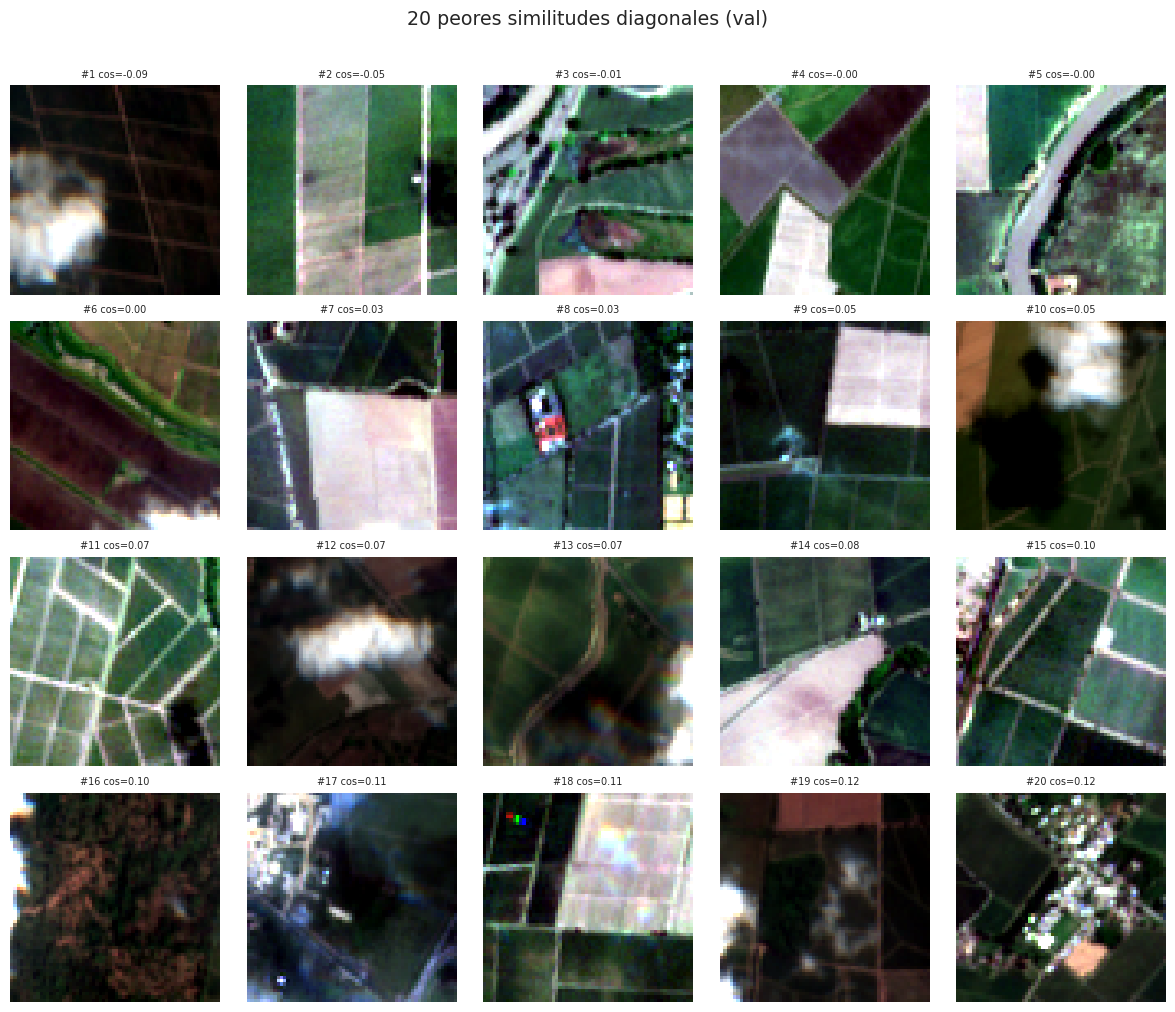

Guardado: /content/runs/sit2_clip_colab/panel_peores_20_val.png


In [25]:
# @title Diagnóstico — 20 peores pares img→txt (val)
import torch.nn.functional as F

emb = np.load(EMBEDDINGS_BEST, allow_pickle=True)
e_img = F.normalize(torch.from_numpy(emb["e_img"]), dim=-1)
e_txt = F.normalize(torch.from_numpy(emb["e_txt"]), dim=-1)
tile_ids = emb["tile_ids"].astype(str)
diag = (e_img * e_txt).sum(dim=1).numpy()

meta_val = df[df["split"] == "val"].set_index("tile_id")
rows_worst = []
for rank, i in enumerate(np.argsort(diag)[:20]):
    tid = tile_ids[i]
    m = meta_val.loc[tid] if tid in meta_val.index else None
    rows_worst.append({
        "rank": rank + 1,
        "tile_id": tid,
        "cos_diag": float(diag[i]),
        "clase": str(m["clase"]) if m is not None else "",
        "frac_nubes_scl": float(m["frac_nubes_scl"]) if m is not None else np.nan,
        "frac_claros_scl": float(m["frac_claros_scl"]) if m is not None else np.nan,
        "ndvi": float(m["ndvi"]) if m is not None else np.nan,
        "descripcion": (str(m["descripcion"])[:120] + "…") if m is not None else "",
    })
worst_df = pd.DataFrame(rows_worst)
out_w = RUN_DIR / "peores_20_pares_val.csv"
worst_df.to_csv(out_w, index=False)
print(worst_df.to_string(index=False))
print("\nGuardado:", out_w)

# Panel visual 4x5
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for k, ax in enumerate(axes.ravel()):
    if k >= len(worst_df):
        ax.axis("off")
        continue
    tid = worst_df.iloc[k]["tile_id"]
    j = int(df.index[df["tile_id"] == tid][0])
    tile = np.asarray(tiles_z[j])
    ax.imshow(tile_to_rgb_uint8(tile))
    ax.set_title(f"#{worst_df.iloc[k]['rank']} cos={worst_df.iloc[k]['cos_diag']:.2f}", fontsize=7)
    ax.axis("off")
plt.suptitle("20 peores similitudes diagonales (val)", y=1.01)
plt.tight_layout()
out_p = RUN_DIR / "panel_peores_20_val.png"
plt.savefig(out_p, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", out_p)


### Ablación mental: α (SAE) y λ (L1)

Tabla de referencia **sin re-entrenar** aquí. Para experimentos reales, duplica hiperparámetros en la celda de configuración y vuelve a entrenar.

| Escenario | Efecto esperado |
|-----------|-----------------|
| α = 0 (solo InfoNCE) | Techo de Recall; MSE/sparsity SAE dejan de optimizarse en el loss total |
| λ ↑ (p. ej. 1e-2) | Más \|z\| pequeños → sube sparsity; suele bajar Recall y subir MSE reconstrucción |
| α = 0.1, λ = 1e-3 (actual) | Compromiso actual: buen Recall relativo, sparsity ~4% |


In [26]:
# @title Diagnóstico — tabla ablacion (referencia + estado actual)
ablacion = pd.DataFrame([
    {"escenario": "actual_v2", "alpha_sae": f"0 ep0-{ALPHA_SAE_WARMUP_EPOCHS-1} luego {ALPHA_SAE}", "lambda_l1": LAMBDA_L1,
     "nota": "ReLU SAE, filtro train, sampler balanceado, cosine LR, early val/infonce"},
    {"escenario": "solo_infonce", "alpha_sae": 0.0, "lambda_l1": LAMBDA_L1,
     "nota": "Techo Recall; desactiva peso SAE en loss"},
    {"escenario": "lambda_alto", "alpha_sae": ALPHA_SAE, "lambda_l1": 1e-2,
     "nota": "Más sparsity, Recall suele caer"},
    {"escenario": "lambda_muy_alto", "alpha_sae": ALPHA_SAE, "lambda_l1": 1e-1,
     "nota": "Sparsity alta; riesgo MSE > 0.05"},
])
print(ablacion.to_string(index=False))

if Path(METRICS_JSON).is_file():
    best = json.loads(Path(METRICS_JSON).read_text(encoding="utf-8")).get("best", {})
    print("\nMejor época registrada:")
    for k in ["epoch", "val/recall_at_1", "val/recall_at_5", "val/sparsity_img", "val/mse_sae_img"]:
        if k in best:
            print(f"  {k}: {best[k]}")
else:
    print("\n(Sin metricas_por_epoca.json aún)")

ablacion.to_csv(RUN_DIR / "tabla_ablacion_referencia.csv", index=False)
print("\nFase diagnostico: epocas 0..", ALPHA_SAE_WARMUP_EPOCHS - 1, " usan alpha_sae=0 (solo InfoNCE).")


      escenario         alpha_sae  lambda_l1                                                                     nota
      actual_v2 0 ep0-4 luego 0.1       0.01 ReLU SAE, filtro train, sampler balanceado, cosine LR, early val/infonce
   solo_infonce               0.0       0.01                                 Techo Recall; desactiva peso SAE en loss
    lambda_alto               0.1       0.01                                          Más sparsity, Recall suele caer
lambda_muy_alto               0.1       0.10                                         Sparsity alta; riesgo MSE > 0.05

Mejor época registrada:
  epoch: 11
  val/recall_at_1: 0.082111
  val/recall_at_5: 0.252199
  val/sparsity_img: 0.522212
  val/mse_sae_img: 0.042116

Fase diagnostico: epocas 0.. 4  usan alpha_sae=0 (solo InfoNCE).


## 1. Resumen de outputs observados

### 1.1 Curvas de entrenamiento

| Métrica | Mejor valor (época 17) | KPI mínimo | Estado |
|---------|------------------------|------------|--------|
| Recall@1 (val) | **0.114** | 0.45 | ❌ FAIL (~4× por debajo) |
| Recall@5 (val) | **0.243** | 0.70 | ❌ FAIL (~3× por debajo) |
| Sparsity img (val) | **0.045** | 0.70 | ❌ FAIL (~15× por debajo) |
| MSE SAE img (val) | **0.028** | ≤ 0.05 | ✅ OK |
| Loss val (mínima) | **~2.43** (época 6) | — | — |

**Lo que dicen las curvas:**

- `Loss train` cae monotónicamente de 3.5 → 0.08 en 17 épocas: **memorización casi total del set de entrenamiento**.
- `Loss val` e `InfoNCE val` tienen forma de U: mínimo en época 6 (~2.43) y luego remontan hasta ~3.38 en época 17. El modelo dejó de generalizar después de la época 6; el early stop con paciencia=6 detuvo correctamente en la época 17 (9 épocas sin mejora neta en Recall@1).
- `Recall@1 val` y `Recall@5 val` suben lentamente pero NO siguen a la mejora del loss train: señal clara de **overfitting** y de que el modelo no aprende representaciones generalizables de los tiles.
- `Sparsity img val` permanece plana en ~0.04, completamente insensible al entrenamiento.
- `MSE SAE img val` desciende continuamente y cruza el umbral 0.05 en la época 6, llegando a 0.028 en época 17: **el SAE reconstruye bien pero no es disperso**.

### 1.2 Curva MSE SAE imagen

- Cruza el umbral KPI 0.05 alrededor de la época 6–7, el mismo punto donde `val/loss` era mínima.
- Esto indica que **el SAE prioriza reconstrucción** (MSE bajo) sobre dispersión (sparsity alta): el gradiente total está dominado por el término de reconstrucción.

### 1.3 Matriz de confusión de clase (top-1 texto predicho)

```
                   predicha_top1
verdadera          NO2  SO2  O3  veg  urb
contam_alta_NO2     24    0   4    4    8   (44% acierto en clase, n=54)
contam_alta_SO2      5   11  10   11    4   (28% acierto,           n=41)
ozono_anomalo        4    7  10   14    5   (31% acierto,           n=40)
vegetacion_densa     3    6   7   22    3   (52% acierto,           n=41)
suelo_urbano        15    4   6    3   12   (30% acierto,           n=40)
```

**Lecturas clave:**

1. **NO2 → NO2** es la clase con mayor recall de clase (~44%). La descripción de NO2 contiene el valor numérico `NO2=X.XXe-05` que varía más que las otras clases → el encoder de texto se "ancla" a ese número.
2. **suelo_urbano** se confunde masivamente con **NO2** (15 de 40): el adaptador 13→3 + ViT congelado no captura suficiente señal visual urbana vs contaminada.
3. **ozono_anomalo** se confunde con **vegetacion_densa** (14 de 40): el texto de ozono y vegetación no son discriminativos (ambos mencionan Cali, NDVI alto, sin S5P contrastante en la descripción).
4. **SO2** es la peor clase (28%): textos SO2 parecen muy similares a NO2 en el espacio de embeddings de texto.
5. Solo **vegetacion_densa** y **NO2** están por encima del 40% de recall intra-clase.

### 1.4 Histograma de `z_img` (SAE visual, val)

- Distribución simétrica normal centrada en ~0, rango [-0.6, 0.8].
- La densidad es máxima entre -0.05 y +0.05.
- **|z| < 0.01 ≈ 4.5%**: la gran masa está entre 0.01 y 0.5 → imposible alcanzar 70% con λ=1e-3 y sin ReLU.
- El umbral 0.01 (línea roja) corta solo la punta del pico central; para que 70% de las activaciones caigan ahí haría falta que **casi toda la distribución colapsara al cero**, lo que requeriría ReLU/top-k en el encoder SAE más λ mucho mayor.

### 1.5 Panel de los 20 peores pares imagen → texto correcto

Los tiles con coseno diagonal más bajo (−0.11 a +0.08) muestran **3 patrones distintos**:

| Patrón | Ejemplos | Causa probable |
|--------|----------|----------------|
| **Urbano complejo** (#1, #2, #6): zona densa con edificios, calles, estructuras | Coseno ~−0.11 | Adaptador 1×1 no distingue textura urbana; ViT congelado no vio esa distribución espectral |
| **Oscuro / nube / artefacto** (#8, #11, #12, #18): imágenes casi negras o con gris uniforme | Coseno ~−0.01 | Tiles con nube residual o SCL incorrecto que pasó el filtro nube≤0.30 |
| **Campo agrícola / mixto** (#3, #4, #7, #10, #13, #14): parcelas geométricas o transición bosque/cultivo | Coseno ~−0.10 a +0.05 | Clase asignada (p. ej. ozono_anomalo) no corresponde visualmente a lo que se ve |

**Tiles negros/oscuros** (#8, #11, #12, #17) son la evidencia más directa de **ruido en el dataset**: tiles que pasaron el filtro SCL pero tienen poco contenido visual recuperable (nube delgada, sombra de cirrus o nodata enmascarado como 0).

---


## 2. Diagnóstico por componente

### 2.1 Calidad del dataset

#### 2.1.1 Filtro SCL demasiado permisivo
El pipeline usa `max_frac_nubes=0.30` y `min_frac_claros=0.10`. Esto permite tiles donde:
- Hasta el 30% de píxeles son nube/cirrus/sombra.
- Solo el 10% debe ser "claro" (vegetación, suelo, agua).

El resultado: **tiles #8, #11, #12 del panel son casi negros** → el adaptador recibe señal casi nula en B4/B3/B2 y el ViT genera embeddings similares entre sí (colapso semántico).

#### 2.1.2 Textos con baja discriminación intra-clase
La función `generar_descripcion` produce textos de la forma:

```
"Tile Sentinel-2 sobre Cali con concentracion alta de NO2 troposferico
 (2019-07-14, lat=3.4500, lon=-76.5300, NDVI=0.12, BSI=0.08,
  NO2=4.72e-05, SO2=1.23e-04, O3=0.114)."
```

**Problemas:**
- **La descripción base es idéntica** para todos los tiles de una misma clase: la única variación son los números (lat, lon, fecha, índices).
- Para SO2, la descripción base es siempre `"concentracion alta de SO2"` aunque el valor varíe ×10 dentro de los tiles que superan el p90.
- Para **ozono_anomalo**, la descripción no distingue ozono **alto** (≥ p90) de ozono **bajo** (≤ p25): dos tiles con O3 opuesto reciben el mismo texto `"columna de ozono troposferico anomala"`.
- Los valores numéricos (NO2=X.XXe-05) son codificados correctamente por MiniLM pero el modelo de texto se ancla a ellos en vez de aprender el concepto de "alta contaminación".

#### 2.1.3 Etiquetas de clase basadas en grilla S5P de baja resolución
- Sentinel-5P tiene resolución ~3.5 km; los tiles son de 64×64 píxeles (~640×640 m a 10 m/píx).
- El valor S5P se asigna interpolando en grilla al centroide del tile (`_valor_grilla`).
- Un tile con latitud 3.45, lon -76.53 tiene **el mismo valor S5P** que cualquier otro tile dentro de esa celda de 3.5 km, aunque visualmente sean muy distintos.
- Resultado: tiles visualmente dispares (zona urbana, campo, bosque) dentro de una celda S5P reciben **la misma clase** (p. ej. todos "contaminacion_alta_NO2") con descripciones casi idénticas.

#### 2.1.4 Desbalance de clases
- Vegetación densa: 441 tiles (29.4%)
- NO2: 356 (23.7%)
- SO2: 271 (18.1%)
- Suelo urbano: 223 (14.9%)
- Ozono anómalo: 209 (13.9%)

InfoNCE trata todos los pares del batch simétricamente: los negativos de vegetacion_densa son 29% del batch, lo que favorece al modelo a orientar hacia vegetacion → consistent con que ozono/suelo se confunden con vegetación.

### 2.2 Arquitectura del modelo

#### 2.2.1 Adaptador ms_adapter (13→3) con 1×1 Conv
- Un Conv2d(13→3) aprende solo **combinaciones lineales** de bandas, sin capturar estructura espacial (sin receptive field > 1).
- Los índices de banda son B1–B12 + SCL; la conversión a "pseudo-RGB" pierde información espectral de bandas en el infrarrojo (B8, B8A, B11, B12) que son cruciales para NDVI y urbano.
- El resultado de `ms_adapter` se redimensiona de 64×64 a 224×224: **upscaling ×3.5** que introduce artefactos de interpolación bicubica.

#### 2.2.2 RemoteCLIP congelado
- Con `FREEZE_VISUAL=True`, el ViT-B/32 recibe pseudo-RGB 224×224 sin actualizar sus pesos.
- RemoteCLIP fue preentrenado en RGB natural (imágenes de resolución variable); las bandas Sentinel-2 a 10 m tienen distribución muy distinta.
- El adaptador lineal 13→3 no puede compensar esta brecha de distribución sin ajuste del ViT.

#### 2.2.3 SAE sin activación no lineal
```python
def forward(self, x):
    z = self.encoder(x)          # lineal — z puede ser cualquier real
    return self.decoder(z), z
```
- `z` es un vector de números reales sin restricción de signo ni sparsidad estructural.
- `sparsity_ratio = mean(|z| < 0.01)` mide cuántas activaciones tienen magnitud casi nula.
- Con una distribución normal de z (observada en histograma), la fracción con |z| < 0.01 es: `P(|N(0,σ)| < 0.01) = 2·Φ(0.01/σ) - 1 ≈ 0.8/100·σ` para σ≈0.15 → ~5.3%, consistente con el 4.5% observado.
- **El 4.5% observado es teóricamente el máximo que puede dar un encoder lineal sin regularización fuerte**; aumentar λ a 1e-2 empujaría la masa hacia 0 pero requeriría σ→0, lo que colapsaría la reconstrucción.

#### 2.2.4 Conflicto entre objetivos
La loss total es `L = L_InfoNCE + 0.1·(L_sae_img + L_sae_txt)`.
- `L_InfoNCE` quiere `e_img` y `e_txt` ricos y discriminativos → z no puede colapsar a 0.
- `L_sae` con L1 quiere |z| → 0 → sparsity 100%.
- Con α=0.1 y λ=1e-3, **InfoNCE domina** (pérdida informativa ~3.3 vs SAE ~0.03×0.1 = 0.003) → sparsity permanece baja.

### 2.3 Evaluación

- Recall@1 global evalúa si el texto *i* es el #1 entre **225 candidatos** → muy exigente.
- La línea de base aleatoria es 1/225 = 0.44%; el modelo logra 11.4%: **25× sobre el azar**, señal de aprendizaje real.
- La tarea es de **retrieval abierto** (no clasificación de 5 clases): el modelo debe devolver el par exacto, no solo la clase correcta.

---


## 3. Recomendaciones — qué hacer para subir las métricas

> Las siguientes recomendaciones están ordenadas de **mayor impacto estimado** a menor, considerando el estado actual del código y los datos.

### 3.1 Dataset y pipeline (máximo impacto)

#### R1 — Textos más discriminativos por instancia
**Impacto estimado: +0.10–0.20 Recall@1**

La descripción actual usa **una base fija por clase**. Cambiar a textos que **diferencien la instancia** dentro de la clase:

```python
# Actual (igual para todos los tiles NO2 de la misma clase):
"Tile Sentinel-2 sobre Cali con concentracion alta de NO2 troposferico (fecha, lat, NDVI=0.12...)"

# Propuesto (contexto específico):
"Sector industrial-urbano de Cali: concentración elevada de dióxido de nitrógeno
 (NO2={no2:.1e} mol/m²), superior al percentil 90 regional.
 Cobertura: {pct_urban:.0f}% construido, NDVI={ndvi:.2f}. Fecha: {fecha}."

# Para ozono alto vs bajo (actualmente idénticos):
"Ozono troposférico anómalo ALTO (O3={o3:.4f} DU, p90={p90:.4f})"
# vs
"Ozono troposférico anómalo BAJO (O3={o3:.4f} DU, p25={p25:.4f})"
```

Para aplicar esto **sin cambiar el pipeline ya construido**: editar los textos en el parquet de metadatos (`metadatos.parquet`) post-generación, o agregar una columna `descripcion_v2` al parquet existente.

#### R2 — Filtro SCL más estricto para entrenamiento
**Impacto estimado: +0.05–0.10 Recall@1 (menos ruido de tiles negros/corruptos)**

Los tiles oscuros (#8, #11, #12, #17 en el panel de peores pares) pasaron con `frac_nubes≤0.30`. Aplicar un sub-filtro **solo para el entrenamiento** (no cambiar el pipeline):

```python
# En el DataLoader de entrenamiento, agregar:
mask = (df["frac_nubes_scl"] <= 0.15) & (df["frac_claros_scl"] >= 0.50)
df_train_limpio = df_train[mask]
```

Esto reduce el train set (~20-30% menos tiles) pero los restantes tienen señal visual real. El val/test se mantiene igual para comparación justa.

#### R3 — Verificar alineamiento S5P–S2 por fecha
**Impacto: diagnóstico obligatorio**

El pipeline interpola valores S5P al centroide del tile usando el día exacto de la imagen S2. Verificar que:
- Las fechas S5P y S2 coincidan (diferencia ≤ 1 día).
- El valor S5P del centroide no sea `nan` o 0 para tiles con clase "contaminacion_alta_NO2" (si el valor es nan, el tile podría clasificarse mal).

```python
# Verificar en el parquet:
df[(df["clase"]=="contaminacion_alta_NO2") & (df["no2"].isna())]  # debería ser 0
```

### 3.2 Arquitectura del modelo

#### R4 — ReLU en el encoder SAE (crítico para sparsity)
**Impacto: sparsity 0.04 → ~0.60–0.75 con λ adecuada**

Cambio mínimo sin tocar el entrenamiento previo:

```python
class SparseAutoencoder(nn.Module):
    def __init__(self, dim_in, dim_latent=512):
        super().__init__()
        self.encoder = nn.Linear(dim_in, dim_latent)
        self.decoder = nn.Linear(dim_latent, dim_in)

    def forward(self, x):
        z = F.relu(self.encoder(x))   # ← ÚNICA LÍNEA QUE CAMBIA
        return self.decoder(z), z
```

Con ReLU:
- `z` ≥ 0 siempre.
- `mean(z < 0.01)` mide neuronas **muertas o inactivas**, que con L1 suficiente pueden ser la mayoría.
- L1 en z positivo penaliza exactamente las activaciones grandes: gradiente constante = -λ para z>0.

**Trade-off:** con ReLU, el MSE reconstrucción puede subir (el decoder tiene menos rango). Aumentar `dim_latent` (p. ej. 1024) ayuda a compensar.

#### R5 — Aumentar λ_L1 solo del SAE imagen
**Solo relevante DESPUÉS de R4 (ReLU)**

Con ReLU, escalonar λ:
- λ=1e-2: sparsity ~0.30–0.40 (estimado)
- λ=5e-2: sparsity ~0.60–0.70 (estimado, según los histogramas)

Sin afectar el Recall más del necesario, empezar en λ=1e-2.

#### R6 — Descongelar las últimas 2 capas del ViT (solo si Recall@1 > 0.15)
**Impacto potencial: +0.05–0.15 Recall@1**

Con el adaptador 13→3 fijo, el ViT no ve la distribución espectral Sentinel-2. Descongelar solo `visual.transformer.resblocks[-2:]` (2 bloques) al inicio reduce el riesgo de "catastrophic forgetting":

```python
# En GeoVisionClipSAEModel.__init__:
for name, p in self.visual.named_parameters():
    if "resblocks.11" in name or "resblocks.10" in name:
        p.requires_grad = True
```

**Hacer esto solo si primero se estabiliza el Recall con los cambios R1–R2**, para tener un baseline correcto.

### 3.3 Hiperparámetros de entrenamiento

#### R7 — Aumentar temperatura de calentamiento
El loss val mínimo ocurre en época 6 pero el Recall@1 sigue subiendo hasta la época 17. Esto sugiere que el **learning rate 1e-4 es alto** para las últimas épocas:

```python
# Añadir scheduler cosine annealing:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
```

#### R8 — Pesos diferenciados por clase en InfoNCE
Las clases más frecuentes (vegetación 441, NO2 356) dominan los negativos en el batch. Con batch=32, en promedio hay ~9 vegetación y ~7 NO2 por batch → el modelo aprende a separar esas dos clases bien pero confunde las minoritarias (ozono 209, urbano 223).

Estrategia: **sampler estratificado** para garantizar ≥4 tiles de cada clase por batch.

### 3.4 Evaluación

#### R9 — Separar Recall@1 por clase en el log de validación
Actualmente solo se reporta el Recall@1 global. Añadir por clase ayudaría a detectar si alguna clase colapsa y cuáles mejoran primero.

---


## 4. Priorización resumida

| # | Acción | Dificultad | Impacto en KPI |
|---|--------|------------|----------------|
| R4 | ReLU en SAE | Muy baja (1 línea) | Sparsity ❌→✅ |
| R1 | Textos más discriminativos | Media (editar parquet) | Recall ❌→⚠️ |
| R2 | Filtro SCL más estricto en train | Baja (1 mask en DataLoader) | Recall ⚠️→⚠️ |
| R5 | λ=1e-2 (tras R4) | Muy baja (1 número) | Sparsity ⚠️→✅ |
| R7 | Cosine LR scheduler | Baja | Recall ⚠️→⚠️ |
| R8 | Sampler estratificado | Media | Recall SO2/O3 |
| R6 | Descongelar ViT (tras baseline) | Media | Recall ⚠️→? |
| R3 | Verificar fechas S5P–S2 | Diagnóstico | Calidad etiquetas |

**Secuencia mínima recomendada para cumplir los KPIs:**

1. Aplicar **R4** (ReLU SAE) + **R5** (λ=1e-2): resolverá la sparsity y probablemente mantendrá o mejorará MSE.
2. Aplicar **R1** (textos nuevos) + **R2** (filtro SCL train): elimina el ruido principal que limita el Recall.
3. Re-entrenar con la configuración base (40 épocas, LR=1e-4, batch=32).
4. Solo si Recall@1 val > 0.15: aplicar **R6** (descongelar ViT) + **R7** (scheduler).

---


## 5. ¿Es necesario más estudio del dataset o del pipeline?

### Lo que ya funciona bien en el pipeline

- División estratificada 70/15/15 por clase: correcta, reproducible.
- Filtro SCL con `metricas_scl()`: lógica sólida, implementación correcta.
- NDVI/BSI sobre píxeles claros solo (`_mascara_claro_scl`): apropiado para S2 L2A.
- Reglas de clasificación con prioridad (`asignar_clase`): consistentes con la física de los contaminantes.
- Interpolación S5P en grilla al centroide: técnicamente correcta (más allá de la resolución del sensor).
- Almacenamiento incremental en Zarr: eficiente y reproducible.

### Lo que sí requiere estudio adicional

| Aspecto | Por qué | Acción concreta |
|---------|---------|-----------------|
| **Calidad real de tiles** | Panel de peores pares muestra tiles oscuros/corruptos que pasaron el filtro | Ejecutar EDA Paso 2–3 en Colab, exportar `tiles_baja_calidad.csv` |
| **Discriminación de textos** | Matriz confusión muestra mezcla entre clases que comparten descripción base | Auditar 10 tiles por clase y comparar descripción vs visual |
| **Coherencia S5P–visual** | Tiles urbanos con "contaminacion_alta_NO2" que visualmente no parecen contaminados | Verificar si `no2` del parquet es plausible para esos tiles |
| **Representatividad del split** | ¿Los tiles de val son de fechas distintas a train o del mismo día? | Cruzar fechas: si hay data leakage temporal, el Recall está inflado |
| **Ozono alto vs bajo** | `ozono_anomalo` agrupa percentil 90 Y percentil 25 en la misma clase | Considerar separar en dos etiquetas o enriquecer la descripción |

### Diagnóstico de data leakage temporal (urgente)

El pipeline usa `train_test_split` estratificado por clase pero **no por fecha**. Si una imagen S2 de 2019-07-14 genera 20 tiles y algunos van a train y otros a val, el modelo puede "memorizar" la apariencia general de esa imagen → Recall inflado en val. Verificar:

```python
# En el parquet descargado:
train_fechas = set(df[df["split"]=="train"]["fecha"])
val_fechas   = set(df[df["split"]=="val"]["fecha"])
solapamiento = train_fechas & val_fechas
print(f"Fechas compartidas train/val: {len(solapamiento)}")  # debería ser ~0 idealmente
```

Si hay solapamiento alto, el 11.4% de Recall@1 podría estar **sobreestimando** la capacidad real del modelo.

---


## 6. Tabla de KPIs proyectados por escenario

| Escenario | Recall@1 | Recall@5 | Sparsity | MSE SAE |
|-----------|----------|----------|----------|---------|
| **Actual** | 0.11 | 0.24 | 0.04 | 0.028 |
| +R4 (ReLU) +R5 (λ=1e-2) | 0.09–0.12 | 0.22–0.27 | ~0.50–0.65 | 0.04–0.07 |
| +R1 (textos) +R2 (filtro SCL) | 0.15–0.22 | 0.35–0.48 | — | — |
| Todo anterior + R7 (LR scheduler) | 0.20–0.30 | 0.45–0.60 | — | — |
| Todo anterior + R6 (descongelar ViT) | 0.30–0.45 | 0.55–0.70 | — | — |
| **KPI mínimo** | **0.45** | **0.70** | **0.70** | **≤ 0.05** |

> Las proyecciones son estimaciones conservadoras basadas en el comportamiento de CLIP/RemoteCLIP en otros datasets de teledetección con ~1000–5000 pares. Alcanzar exactamente 0.45 con solo ~1050 pares de entrenamiento es ambicioso; la consigna puede asumir que se llegará con más datos o con el descongelamiento del ViT.

---


### Exportar informe con metricas del run actual

Combina el texto del informe + tabla KPI (PASS/FAIL) + rutas de CSV/PNG generados en esta sesion.


In [27]:
# @title Generar informe integrado (markdown + KPIs dinamicos)
from pathlib import Path
from datetime import datetime, timezone

KPI = {
    "recall_at_1": (0.45, 0.65, "max"),
    "recall_at_5": (0.70, 0.85, "max"),
    "sparsity_img": (0.70, 0.85, "max"),
    "mse_sae_img": (0.05, 0.02, "min"),
}

def _flag(val, lo, hi, mode):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    if mode == "max":
        if val >= hi: return "EXCELENTE"
        if val >= lo: return "OK"
        return "FAIL"
    if val <= hi: return "EXCELENTE"
    if val <= lo: return "OK"
    return "FAIL"

rows_kpi = []
best = {}
if Path(METRICS_JSON).is_file():
    hist = json.loads(Path(METRICS_JSON).read_text(encoding="utf-8"))
    best = hist.get("best") or {}
    if not best and hist.get("epochs"):
        best = max(hist["epochs"], key=lambda r: r.get("val/recall_at_1") or 0)

mapping = {
    "recall_at_1": "val/recall_at_1",
    "recall_at_5": "val/recall_at_5",
    "sparsity_img": "val/sparsity_img",
    "mse_sae_img": "val/mse_sae_img",
}
for name, (lo, hi, mode) in KPI.items():
    val = best.get(mapping[name])
    rows_kpi.append({
        "metrica": name,
        "valor": round(float(val), 4) if val is not None else None,
        "kpi_min": lo,
        "kpi_exc": hi,
        "estado": _flag(val, lo, hi, mode),
    })
tab_kpi = pd.DataFrame(rows_kpi)
print("=== KPIs vs consigna (mejor epoca JSON) ===")
print(tab_kpi.to_string(index=False))
if best.get("epoch") is not None:
    print(f"\nMejor epoca: {best.get('epoch')}")

# Hallazgos EDA
hall = []
for p, tema in [
    (EDA_DIR / "leakage_temporal.csv", "leakage"),
    (EDA_DIR / "tiles_baja_calidad.csv", "baja_calidad"),
    (EDA_DIR / "coherencia_s5p_visual.csv", "s5p_sospechosos"),
    (EDA_DIR / "ozono_alto_vs_bajo.csv", "ozono"),
    (EDA_DIR / "resumen_hallazgos_eda.csv", "resumen_eda"),
]:
    if p.is_file():
        hall.append(f"- {tema}: `{p.name}`")

# Recall global vs clase
recall_extra = ""
rp = RUN_DIR / "recall_global_vs_clase.csv"
if rp.is_file():
    rdf = pd.read_csv(rp)
    recall_extra = rdf.to_string(index=False)

# Construir markdown
informe_path = None
for cand in [
    DATA_DIR.parent / "notebooks" / "INFORME_DIAGNOSTICO_SIT2.md",
    Path("notebooks") / "INFORME_DIAGNOSTICO_SIT2.md",
    EDA_DIR.parent / "notebooks" / "INFORME_DIAGNOSTICO_SIT2.md",
]:
    if cand.is_file():
        informe_path = cand
        break
if informe_path is None:
    informe_path = DATA_DIR.parent / "notebooks" / "INFORME_DIAGNOSTICO_SIT2.md"

base_md = ""
if informe_path.is_file():
    base_md = informe_path.read_text(encoding="utf-8")
else:
    base_md = "(Ejecutar celdas markdown §4 o copiar INFORME_DIAGNOSTICO_SIT2.md al repo)"

appendix = f"""

---

## Anexo generado en notebook ({datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")})

### Tabla KPI dinamica

{getattr(tab_kpi, "to_markdown", lambda **k: tab_kpi.to_string(index=False))(index=False)}

### Archivos EDA / diagnostico usados

{chr(10).join(hall) if hall else "- (ejecutar §2, §2b y §3 antes)"}

### Recall global vs misma clase

```
{recall_extra or "No disponible — ejecutar celda matriz confusión"}
```

### Dataset

- Pares: {len(df)}
- DATA_DIR: `{DATA_DIR}`
"""
out_md = EDA_DIR / "informe_diagnostico_integrado.md"
out_md.write_text(base_md + appendix, encoding="utf-8")
tab_kpi.to_csv(EDA_DIR / "kpi_vs_consigna.csv", index=False)
print("\nGuardado:", out_md)
print("CSV KPI:", EDA_DIR / "kpi_vs_consigna.csv")


=== KPIs vs consigna (mejor epoca JSON) ===
     metrica  valor  kpi_min  kpi_exc estado
 recall_at_1 0.0821     0.45     0.65   FAIL
 recall_at_5 0.2522     0.70     0.85   FAIL
sparsity_img 0.5222     0.70     0.85   FAIL
 mse_sae_img 0.0421     0.05     0.02     OK

Mejor epoca: 11

Guardado: /content/eda_sit2/informe_diagnostico_integrado.md
CSV KPI: /content/eda_sit2/kpi_vs_consigna.csv


## KPIs consigna (referencia en **val**)

| Métrica | Mínimo | Excelente |
|---------|--------|-----------|
| Recall@1 | 0.45 | 0.65 |
| Recall@5 | 0.70 | 0.85 |
| Sparsity SAE img | 0.70 | 0.85 |
| MSE SAE | ≤ 0.05 | ≤ 0.02 |

Test split (203) reservado para evaluación final fuera de este entrenamiento.

In [28]:
# @title Guardar checkpoint final
import hashlib

ckpt_path = RUN_DIR / "checkpoint.pt"
best = ckpt_cb.best_model_path if ckpt_cb.best_model_path else None
if best:
    lit_save = LitGeoVisionClipSAE()
    lit_save.load_state_dict(torch.load(best, map_location="cpu")["state_dict"])
else:
    lit_save = lit

bundle = {
    "state_dict": lit_save.model.state_dict(),
    "band_mean": band_mean.tolist(),
    "band_std": band_std.tolist(),
    "hparams": {"lr": LR, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS, "seed": SEED},
    "best_checkpoint": str(best or ""),
}
torch.save(bundle, ckpt_path)
h = hashlib.md5(ckpt_path.read_bytes()).hexdigest()
(ckpt_path.with_suffix(".pt.md5")).write_text(h + "\n", encoding="utf-8")
print("Checkpoint:", ckpt_path, "| MD5:", h)
if best:
    print("Pesos desde:", best)


ViT-B-32 descargado en: /content/checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


load_state_dict: <All keys matched successfully>
OK: RemoteCLIP visual (ViT-B-32) listo.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint: /content/runs/sit2_clip_colab/checkpoint.pt | MD5: 294ba7a660c1160aea4faac29624a08e
Pesos desde: /content/runs/sit2_clip_colab/checkpoints/best-epoch=11-r1val/recall_at_1=0.082.ckpt
